# Probability of Default (PD) Prediction Using Machine Learning

## Table of Contents

- 1. [Project Overview](#1-project-overview)
- 2. [Data Loading and Initial Exploration](#2-data-loading-and-initial-exploration)
- 3. [Initial Data Cleaning and Dataset Refinement](#3-initial-data-cleaning-and-dataset-refinement)
   - [3.1 Target Variable Creation and Distribution](#31-target-variable-creation-and-distribution)
   - [3.2 Removal of Data Leakage Features and Target Variable](#32-removal-of-data-leakage-features-and-target-variable)
   - [3.3 Initial Missing Value Assessment and Column Filtering](#33-initial-missing-value-assessment-and-column-filtering)
   - [3.4 Dataset Refinement](#34-dataset-refinement)
   - [3.5 Missing Value Imputation Strategy](#35-missing-value-imputation-strategy)
   - [3.6 Variable Encoding and Feature Transformation](#36-variable-encoding-and-feature-transformation)

- 4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)
   - [4.1 Loan Status Distribution and Class Imbalance](#41-loan-status-distribution-and-class-imbalance)
   - [4.2 Correlation Analysis](#42-correlation-analysis)
   - [4.3 Interest Rate Analysis](#43-interest-rate-analysis)
   - [4.4 Loan Grade Analysis](#44-loan-grade-analysis)
   - [4.5 Debt-to-Income (DTI) Analysis](#45-debt-to-income-dti-analysis)
   - [4.6 Annual Income Analysis](#46-annual-income-analysis)
   - [4.7 Loan Purpose Analysis](#47-loan-purpose-analysis)

- 5. [Training Data Preparation](#5-training-data-preparation)
   - [5.1 Feature and Target Selection](#51-feature-and-target-selection)
   - [5.2 Train-Test Split](#52-train-test-split)
   - [5.3 Feature Scaling](#53-feature-scaling)

- 6. [Modeling](#6-modeling)
   - [6.1 Logistic Regression](#61-logistic-regression)
      - [6.1.1 Baseline Logistic Regression](#611-baseline-logistic-regression)
      - [6.1.2 Balanced Logistic Regression (Ridge)](#612-balanced-logistic-regression-ridge)
      - [6.1.3 Balanced Logistic Regression (Lasso)](#613-balanced-logistic-regression-lasso)
      - [6.1.4 Logistic Regression with SMOTE Oversampling](#614-logistic-regression-with-smote-oversampling)
      - [6.1.5 Hyperparameter Tuning for Logistic Regression](#615-hyperparameter-tuning-for-logistic-regression)

   - [6.2 Random Forest](#62-random-forest)
      - [6.2.1 Baseline Random Forest](#621-baseline-random-forest)
      - [6.2.2 Random Forest with SMOTE Oversampling](#622-random-forest-with-smote-oversampling)
      - [6.2.3 Hyperparameter Tuning for Random Forest](#623-hyperparameter-tuning-for-random-forest)

   - [6.3 Extreme Gradient Boosting (XGBoost)](#63-extreme-gradient-boosting-xgboost)
      - [6.3.1 Baseline XGBoost](#631-baseline-xgboost)
      - [6.3.2 Hyperparameter Tuning for XGBoost](#632-hyperparameter-tuning-for-xgboost)
        
- [7. Model Comparison](#7-model-comparison)
  - [7.1 Performance Summary of the Four Best Models](#71-performance-summary-of-the-four-best-models)
  - [7.2 ROC Curve Comparison](#72-roc-curve-comparison)
  - [7.3 Top 20 Important Features](#73-top-20-important-features)

- [8. Conclusions and Recommendations](#8-conclusions-and-recommendations)
  - [8.1 Summary of Findings](#81-summary-of-findings)
  - [8.2 Recommended Model](#82-recommended-model)
  - [8.3 Future Work](#83-future-work)

## 1. Project Overview
This project aims to develop a machine learning model to predict the probability of loan default using LendingClub loan data. The objective is to identify borrowers at higher risk of default by analyzing borrower's characteristics, loan attributes, and financial information. Different classification models were developed, evaluated,and hyperparameter tuned and compared to identify the model that achieved the strongest predictive performance while maintaining model interpretability.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv
/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/LCDataDictionary.xlsx


In [2]:

#Checking the dataset directory
os.listdir('/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv')

['loan.csv', 'LCDataDictionary.xlsx']

## 2. Data Loading and Initial Exploration

We begin by loading the full LendingClub dataset from Kaggle and examining its dimensions. The dataset contains 2,260,668 rows and 145 columns. To improve computational efficiency, a random sample of 75,000 observations is selected using a fixed random seed (random_state = 42). Random sampling helps ensure that the sample reflects the overall distribution of the original dataset while significantly reducing processing time during data cleaning, exploratory analysis, and model development.

Before loading the data, we verify the dataset directory to confirm the presence of the main dataset file and the accompanying data dictionary. The sampled dataset is then inspected to examine its dimensions, column names, data types, and overall structure before proceeding with preprocessing and feature engineering.

In [3]:
import pandas as pd
# Load te full Lending Club dataset
df = pd.read_csv(
    '/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv',
    low_memory = False
)

df.shape


(2260668, 145)

In [4]:
# Take a random sample of 75,000 rows
df_sample = df.sample(
    n = 75000, 
    random_state = 42
)
df_sample.head()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
1758049,NaN,NaN,35000,35000,35000.0,36 months,12.12,1164.51,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
686533,NaN,NaN,30000,30000,30000.0,60 months,10.75,648.54,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
900721,NaN,NaN,15000,15000,15000.0,36 months,7.49,466.53,A,A4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1727912,NaN,NaN,24000,24000,24000.0,60 months,21.15,651.31,E,E2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
539691,NaN,NaN,14400,14400,14400.0,36 months,8.59,455.18,A,A5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_sample.shape

(75000, 145)

In [6]:
# Checking all the columns
pd.set_option('display.max_columns', None)
list(df_sample.columns)

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [7]:
df_sample['loan_status'].value_counts()

loan_status
Fully Paid                                             34567
Current                                                30514
Charged Off                                             8669
Late (31-120 days)                                       723
In Grace Period                                          307
Late (16-30 days)                                        131
Does not meet the credit policy. Status:Fully Paid        57
Does not meet the credit policy. Status:Charged Off       31
Default                                                    1
Name: count, dtype: int64

The `loan_status` column contains different loan outcome categories, such as *Current*, *Fully Paid*, *Charged Off*, and *Default*. Using `value_counts()` provides the frequency of each category within the sampled dataset. 

## 3. Initial Data Cleaning and Dataset Refinement
This section focuses on preparing and refining the dataset prior to exploratory analysis and predictive modeling. The process includes defining the target variable, removing potential data leakage features, examining missing values, reviewing data types, and transforming variables into formats suitable for analysis. Additional feature refinement steps are performed to reduce noise, improve data quality, and ensure that the remaining variables reflect information available at the time of loan origination

### 3.1 Target Variable Creation and Distribution

The `loan_status` variable represents the current or final repayment status of each loan and serves as the foundation for defining the target variable in this analysis. The objective of this project is to predict loan default using a definition that aligns more closely with real-world credit risk practices. Under this approach, only loans that resulted in a final default outcome were classified as defaults.

To construct the binary target variable, loans were categorized into two groups based on their final repayment outcomes. Loans with a status of **“Charged Off”**, **“Default”**, or **“Does not meet the credit policy: Status: Charged Off”** were classified as `default loans` (bad_status = 1). All remaining loan statuses, including **“Fully Paid”**, **“Current”**, **“In Grace Period”**, and delinquent statuses such as **“Late (16–30 days)”** and **“Late (31–120 days)”**, were classified as `non-default` loans (bad_status = 0).

This classification reflects the distinction between borrowers who ultimately defaulted on their obligations and those who did not. While some loans may experience temporary delinquency, late payment alone does not necessarily result in default. The binary target variable therefore focuses on realized default events, providing a more realistic framework for credit risk modeling.

In [8]:
# Defining categories

bad_status = [
    'Charged Off',
    'Does not meet the credit policy. Status:Charged Off',
    'Default'
]

good_status = [
    'Fully Paid',
    'Current',
    'Late (31-120 days)',
    'In Grace Period',
    'Late (16-30 days)',
    'Does not meet the credit policy. Status:Fully Paid'
]

In [9]:
# Creating a binary target

df_sample['bad_status'] = df['loan_status'].apply(lambda x:1 if x in bad_status else 0)

In [10]:
# Check the result
df_sample['bad_status'].value_counts()

bad_status
0    66299
1     8701
Name: count, dtype: int64

In [11]:
# Checking the proportion of Default vs Non-Default
df_sample['bad_status'].value_counts(normalize = True)

bad_status
0    0.883987
1    0.116013
Name: proportion, dtype: float64

After defining the binary target variable `bad_status`, the distribution of loan outcomes was examined using the `value_counts()` method, which counts the number of occurrences of each unique value in the column. The result shows that the majority of loans are classified as non-default (0), with 66,299 observations out of 50,000 sample, and 8,701 loans are classified as default (1).

This indicates that the dataset is moderately imbalanced, with approximately 88.4% non-default loans and 11.6% default loans. Such class imbalance is common in credit risk datasets, as only a minority of borrowers ultimately default on their loans.

### 3.2 Removal of Data Leakage Features and Target Variable 


Certain variables were removed from the dataset due to potential data leakage, as they contain information that becomes available only after the loan has been issued or after repayment behavior has already occurred. Including such variables would result in unrealistic model performance, since they effectively reveal the outcome of the loan.

Examples of these variables include total payment amounts, recovery-related metrics, and last payment information, all of which are directly influenced by whether a borrower ultimately defaults. To ensure that the model reflects a real-world prediction scenario at the time of loan origination, these columns were excluded from the analysis.

The following variables were identified as containing post-outcome or repayment-related information and were therefore removed: total payment variables (total_pymnt, total_pymnt_inv), recovery-related variables (recoveries, collection_recovery_fee), repayment components (total_rec_prncp, total_rec_int, total_rec_late_fee), and variables reflecting repayment timing and remaining balance (last_pymnt_d, last_pymnt_amnt, out_prncp, out_prncp_inv).

In [12]:
# Creating leakage list:

leakage_cols = [
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'out_prncp',
    'out_prncp_inv'
]

In [13]:
# Dropping the leakage columns from our dataset:

df_sample = df_sample.drop(columns = leakage_cols, errors = 'ignore')

### Removal of Target Variable Source

After constructing the binary target variable bad_status, the original loan_status column has to be removed from the dataset. This is because loan_status directly reflects the final outcome of each loan and was used to derive the target variable. Keeping this column in the dataset would introduce target leakage, allowing the model to trivially infer the outcome and resulting in misleading performance. Therefore, it was excluded to ensure that the model relies only on independent features available at the time of loan origination.

In [14]:
# Dropping 'loan_status' since we have our binary variable 
df_sample = df_sample.drop(columns=['loan_status'], errors='ignore')

In [15]:
# Checking the new shape of the dataset:
df_sample.shape

(75000, 134)

After filtering the dataset and removing leakage variables and target variable source "loan_status", the number of columns decreased from 145 to 134. Although 12 leakage columns were removed, one new binary target column, `default`, was added, resulting in a net reduction of 11 columns.

### 3.3 Initial Missing Values Assessment and Column Filtering

To understand the quality of the dataset, we need to examine missing values across all columns. I used the *isnull().sum()* function to count how many missing values were present in each variable and sort the results to identify the columns with the most missing data. After, I calculated the percentage of missing values relative to the total number of rows. These results were be combined into a new DataFrame (`missing_df_sample`) to clearly summarize and analyze the extent of missing data in the dataset.

In [16]:
# Counting how many missing values are in each variable with isnull().sum()
missing = df_sample.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df_sample)) * 100

missing_df_sample = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
})

missing_df_sample.head(20)

,missing_count,missing_percent
id,75000,100.000000
member_id,75000,100.000000
url,75000,100.000000
orig_projected_additional_accrued_interest,74706,99.608000
hardship_last_payment_amount,74641,99.521333
hardship_length,74641,99.521333
payment_plan_start_date,74641,99.521333
hardship_dpd,74641,99.521333
hardship_payoff_balance_amount,74641,99.521333
hardship_loan_status,74641,99.521333


In [17]:
# 20% threshold (dropping high - missing columns (>20%))
cols_20 = missing_df_sample[missing_df_sample['missing_percent'] > 20].index
df_sample_20 = df_sample.drop(columns=cols_20)
df_sample_20.shape

(75000, 76)

In [18]:
# Assigning 20% threshold missingness to our sample of dataset
df_sample = df_sample_20.copy()

In [19]:
df_sample.shape

(75000, 76)

A 20% threshold was selected to balance data quality and feature retention. The resulting dataset retained 76 features while significantly reducing missingness.

In [20]:
# Check the remaining missing values:
df_sample.isnull().sum().sort_values(ascending = False).head(10)

mths_since_recent_inq    9970
emp_title                5505
num_tl_120dpd_2m         5080
emp_length               4838
mo_sin_old_il_acct       4615
bc_util                  2529
percent_bc_gt_75         2499
bc_open_to_buy           2486
mths_since_recent_bc     2444
pct_tl_nvr_dlq           2320
dtype: int64

After applying a 20% missing value threshold, variables with extremely high levels of missing data were removed from the dataset. The remaining features exhibit moderate levels of missingness, generally below 20%.

Many of these variables are related to borrower behavior and credit activity, such as recent inquiries and delinquency measures. In some cases, missing values may not be random but instead reflect the absence of a specific event (e.g., no recent credit inquiries). Therefore, these variables were retained, and their missing values will be handled carefully during imputation to preserve potentially useful information for modeling.

### 3.4 Dataset Refinement

At this stage, the dataset is refined by removing variables that are unlikely to improve model performance or that could introduce bias into the predictive model. The objective is to retain only features that are relevant and appropriate for predicting loan default while eliminating unnecessary information before handling missing values and model development.

Several variables are removed because they provide little predictive value, contain high-cardinality text, remain nearly constant across observations, or represent information unavailable at the time a loan application is evaluated. Removing these variables simplifies the dataset, reduces noise, and helps prevent data leakage.

Specifically, identifier and text-based variables such as zip_code, title, and emp_title are excluded because they contain thousands of unique values with limited generalizability. Variables such as pymnt_plan and policy_code are removed because they exhibit little variation and contribute minimal predictive information.

Additionally, last_credit_pull_d and debt_settlement_flag are excluded because they contain information generated after loan origination. Including these variables would allow the model to learn from future information that would not be available when making real-world lending decisions, resulting in data leakage.

After completing feature refinement, the remaining dataset is used for missing-value analysis, imputation, and subsequent preprocessing before model training.

In [21]:
# Dropping columns with low predictive value, high noise, or potential data leakage

drop_cols = [
    'zip_code',
    'title',
    'emp_title',
    'pymnt_plan',
    'policy_code',
    'debt_settlement_flag'
]

df_sample = df_sample.drop(columns=drop_cols)

In [22]:
# Drop last_credit_pull_d as it contains information from after loan origination, 
# which would introduce data leakage into the model:

df_sample = df_sample.drop(columns=['last_credit_pull_d'])

In [23]:
print(f'Remaining columns: {df_sample.shape[1]}')

Remaining columns: 69


In [24]:
# Columns with no missing values:
no_missing_cols = df_sample.columns[df_sample.isnull().sum() == 0]

# Columns with missing values:
missing_cols = df_sample.columns[df_sample.isnull().sum() > 0]

In [25]:
# Checking the amount of each:
len(no_missing_cols)

20

In [26]:
len(missing_cols)

49

In [27]:
# Split missing columns by type:
missing_num_cols = df_sample[missing_cols].select_dtypes(include=['int64', 'float64']).columns
missing_cat_cols = df_sample[missing_cols].select_dtypes(include=['object']).columns

In [28]:
# Printing columns with missing values separately numerical from categorical
print("Numerical columns with missing values:")
print(list(missing_num_cols))

print("\nCategorical columns with missing values:")
print(list(missing_cat_cols))

Numerical columns with missing values:
['dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit']

Categorical columns with missing values:
['emp_length', 'earliest_cr_line']


In [29]:
# Starting with categorical column 'emp_length':
df_sample['emp_length'].head(20)

1758049     < 1 year
686533       2 years
900721       5 years
1727912      5 years
539691       3 years
2153213     < 1 year
47643         1 year
1360732      9 years
1779694    10+ years
511378       3 years
506300       5 years
1262689    10+ years
1094496          NaN
578794      < 1 year
1421198      2 years
1228621      9 years
992325       4 years
93762        9 years
754133       5 years
1815417      5 years
Name: emp_length, dtype: object

In [30]:
df_sample['emp_length'].isnull().sum()

np.int64(4838)

In [31]:
# Inspecting unique values first:

sorted(df_sample['emp_length'].dropna().unique())

['1 year',
 '10+ years',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '< 1 year']

In [32]:
# Step 1: Converting special cases to string numbers (not integers!)
df_sample['emp_length'] = df_sample['emp_length'].replace({
    '< 1 year': '1',
    '10+ years': '10'
})

# Step 2: Removing text
df_sample['emp_length'] = df_sample['emp_length'].str.replace(' years', '', regex=False)
df_sample['emp_length'] = df_sample['emp_length'].str.replace(' year', '', regex=False)
df_sample['emp_length'] = df_sample['emp_length'].str.strip()

# Step 3: Converting to numeric
df_sample['emp_length'] = pd.to_numeric(df_sample['emp_length'], errors='coerce')

In [33]:
# Verifying that the amount of NaN is the same as before
df_sample['emp_length'].isnull().sum()

np.int64(4838)

Approximately 6.4% of observations (4,838 out of 75,000) have missing values in the employment length variable. Since this proportion is relatively small and employment history is an important indicator of borrower stability, the variable is going to be retained. The categorical values will be converted into numeric form, and a separate binary indicator is going to be created to capture missing employment information, allowing the model to learn whether missingness itself is predictive of default risk.

In [34]:
# Another check that everything besides the NaN converted correctly:
df_sample['emp_length'].value_counts(dropna=False)

emp_length
10.0    24874
1.0     11189
2.0      6760
3.0      5996
NaN      4838
5.0      4584
4.0      4515
6.0      3503
7.0      3094
8.0      3050
9.0      2597
Name: count, dtype: int64

In [35]:
# Create a binary indicator to capture missing employment length, 
# allowing the model to learn from missingness:

df_sample['emp_length_missing'] = df_sample['emp_length'].isnull().astype(int)

In [36]:
# Checking the column:
df_sample['emp_length_missing'].value_counts()

emp_length_missing
0    70162
1     4838
Name: count, dtype: int64

In [37]:
# Replace missing employment length values with -1 in the original emp_length column
# to retain observations for modeling :

df_sample['emp_length'] = df_sample['emp_length'].fillna(-1)

In [38]:
# Making sure there is no more missing values in the column:
df_sample['emp_length'].isnull().sum()

np.int64(0)

In [39]:
# Checking the new values of the column, there should be 3220 of -1
df_sample['emp_length'].value_counts(dropna=False)

emp_length
 10.0    24874
 1.0     11189
 2.0      6760
 3.0      5996
-1.0      4838
 5.0      4584
 4.0      4515
 6.0      3503
 7.0      3094
 8.0      3050
 9.0      2597
Name: count, dtype: int64

### 3.5 Missing Value Imputation Strategy

To handle the remaining missing values in the dataset, variables are going to be grouped according to their meaning rather than treated individually. This approach ensures that missing data are filled in a way that is consistent with the underlying financial interpretation of each feature.

Event-based variables, such as counts of inquiries, delinquencies, charge-offs, bankruptcies, or tax liens, are imputed with zero because missing values in these cases are interpreted as the absence of the event. Time-based variables that measure the number of months since a financial event are imputed with -1, which is used as a placeholder to indicate that the event has never occurred. Continuous financial variables, such as balances, credit limits, utilization measures, and other numeric account-level characteristics, are imputed using the median to preserve the overall distribution of the data while reducing sensitivity to outliers.

This grouped imputation strategy provides a structured and defensible way to complete the dataset for modeling without relying on a single rule for all variables.

In [40]:
# Event-based variables: missing values indicate that no event occurred,
# so they are safely imputed with 0

event_cols = [
    'inq_last_6mths',
    'collections_12_mths_ex_med',
    'chargeoff_within_12_mths',
    'num_accts_ever_120_pd',
    'num_tl_30dpd',
    'num_tl_90g_dpd_24m',
    'num_tl_120dpd_2m',
    'pub_rec_bankruptcies',
    'tax_liens'
]


# Keep only columns that still exist in the dataset
event_cols = [col for col in event_cols if col in df_sample.columns]

df_sample[event_cols] = df_sample[event_cols].fillna(0)

In [41]:
# Checking one of the event-based columns
df_sample['inq_last_6mths'].value_counts()

inq_last_6mths
0.0     45936
1.0     19226
2.0      6626
3.0      2351
4.0       600
5.0       210
6.0        40
8.0         4
10.0        3
7.0         3
9.0         1
Name: count, dtype: int64

In [42]:
# Time-based variables: missing values indicate that the event has never occurred,
# so they are imputed with -1 to explicitly capture this condition

time_cols = [
    'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'mths_since_recent_bc',
    'mths_since_recent_inq'
]

df_sample[time_cols] = df_sample[time_cols].fillna(-1)

In [43]:
# Checking one of the time-based variables:
df_sample['mo_sin_old_il_acct'].value_counts()

mo_sin_old_il_acct
-1.0      4615
 127.0     866
 128.0     852
 133.0     850
 137.0     838
          ... 
 412.0       1
 436.0       1
 357.0       1
 455.0       1
 487.0       1
Name: count, Length: 415, dtype: int64

In [44]:
# Continuous numeric columns: missing values are imputed using the median
# to preserve the distribution and reduce the influence of outliers

continuous_cols = [
    col for col in missing_num_cols
    if col not in event_cols + time_cols
]

df_sample[continuous_cols] = df_sample[continuous_cols].fillna(df[continuous_cols].median())

In [45]:
# Grouping all of the columns with treated missing values together:

treated_num_cols = event_cols + time_cols + continuous_cols

In [46]:
# Checking if there are any left out columns:

left_out_num_cols = [col for col in missing_num_cols if col not in treated_num_cols]
print(left_out_num_cols)

[]


In [47]:
# Checking the overview off the dataset:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75000 entries, 1758049 to 1775909
Data columns (total 70 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   75000 non-null  int64  
 1   funded_amnt                 75000 non-null  int64  
 2   funded_amnt_inv             75000 non-null  float64
 3   term                        75000 non-null  object 
 4   int_rate                    75000 non-null  float64
 5   installment                 75000 non-null  float64
 6   grade                       75000 non-null  object 
 7   sub_grade                   75000 non-null  object 
 8   emp_length                  75000 non-null  float64
 9   home_ownership              75000 non-null  object 
 10  annual_inc                  75000 non-null  float64
 11  verification_status         75000 non-null  object 
 12  issue_d                     75000 non-null  object 
 13  purpose                     

Variables that measure the timing of credit-related events, such as those starting with `mo_sin_` or `mths_since_`, represent the number of months since specific events (e.g., account openings or recent activity).

These variables capture the length and recency of a borrower’s credit history. In many cases, missing values in these fields indicate that the event has never occurred rather than simply being unreported.

To preserve this distinction, missing values are imputed with -1, explicitly encoding the absence of the event. This allows the model to differentiate between recent activity, older activity, and no recorded occurrence.

In contrast, continuous financial variables and account-level characteristics, including account counts such as mortgage accounts (`mort_acc`), are imputed using the median, as missing values in these variables reflect incomplete reporting rather than the absence of activity.

### 3.6 Variable Encoding and Feature Transformation
This section focuses on transforming and encoding variables into formats suitable for analysis and predictive modeling. Object-type variables are examined to determine whether they represent categorical information, numerical values stored as text, or date-related features requiring specialized treatment. Several variables are converted into numerical representations, including transformations of date variables into time-based features and mappings of ordinal credit grading variables into structured numerical formats. Additional preprocessing steps include the creation of binary indicator variables, conversion of boolean variables into integers, and one-hot encoding of categorical features using dummy variables. These transformations help standardize the dataset and prepare all remaining variables for exploratory analysis and machine learning modeling.

In [48]:
# Extract all columns with object data type
object_cols = df_sample.select_dtypes(include='object').columns.tolist()

# Print them
object_cols

['term',
 'grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'issue_d',
 'purpose',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'application_type',
 'hardship_flag',
 'disbursement_method']

In [49]:
# Taking a look at our "object" columns:
df_sample[object_cols].head(100)

,term,grade,sub_grade,home_ownership,verification_status,issue_d,purpose,addr_state,earliest_cr_line,initial_list_status,application_type,hardship_flag,disbursement_method
1758049,36 months,B,B3,RENT,Verified,Jun-2013,debt_consolidation,TX,Nov-1997,w,Individual,N,Cash
686533,60 months,B,B4,RENT,Verified,Apr-2016,credit_card,TX,Jun-2011,f,Individual,N,Cash
900721,36 months,A,A4,OWN,Source Verified,Oct-2016,small_business,MD,Apr-1996,w,Individual,N,Cash
1727912,60 months,E,E2,RENT,Source Verified,Sep-2013,debt_consolidation,NC,Aug-1998,f,Individual,N,Cash
539691,36 months,A,A5,MORTGAGE,Not Verified,Aug-2016,debt_consolidation,MO,Dec-2003,w,Individual,N,Cash
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515713,60 months,B,B5,MORTGAGE,Verified,Sep-2016,debt_consolidation,MA,Aug-1988,w,Individual,N,Cash
755134,60 months,C,C4,MORTGAGE,Not Verified,Feb-2016,debt_consolidation,IL,Aug-2003,w,Individual,N,Cash
765186,36 months,A,A2,MORTGAGE,Not Verified,Feb-2016,home_improvement,MO,Aug-2003,w,Individual,N,Cash
543113,60 months,C,C4,RENT,Not Verified,Aug-2016,vacation,FL,Nov-1986,w,Individual,N,Cash


In [50]:
# Converting term column to numeric:
df_sample['term'] = df_sample['term'].str.extract(r'(\d+)').astype(int)

In [51]:
# Checking the 'term' column:
df_sample['term'].head()

1758049    36
686533     60
900721     36
1727912    60
539691     36
Name: term, dtype: int64

In [52]:
# Convert date variables to datetime:

df_sample['issue_d'] = pd.to_datetime(df_sample['issue_d'])
df_sample['earliest_cr_line'] = pd.to_datetime(df_sample['earliest_cr_line'])

/tmp/ipykernel_129/659374769.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sample['issue_d'] = pd.to_datetime(df_sample['issue_d'])
/tmp/ipykernel_129/659374769.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sample['earliest_cr_line'] = pd.to_datetime(df_sample['earliest_cr_line'])


In [53]:
df_sample['issue_d'].head()

1758049   2013-06-01
686533    2016-04-01
900721    2016-10-01
1727912   2013-09-01
539691    2016-08-01
Name: issue_d, dtype: datetime64[ns]

In [54]:
df_sample['earliest_cr_line'].head()

1758049   1997-11-01
686533    2011-06-01
900721    1996-04-01
1727912   1998-08-01
539691    2003-12-01
Name: earliest_cr_line, dtype: datetime64[ns]

In [55]:
# Checking "initial_list_status" if theres any value in this column:
df_sample['initial_list_status'].value_counts()


initial_list_status
w    51008
f    23992
Name: count, dtype: int64

The variable `initial_list_status` indicates how the loan was funded at origination. 
A value of 'w' (whole loan) means the loan was funded by a single investor or institution, 
while 'f' (fractional) means the loan was split across multiple investors. This feature 
may capture differences in loan structure and investor behavior, which could potentially 
influence default risk. 

For modeling purposes, the variable is converted into a binary numeric format, where 
'w' is mapped to 1 and 'f' is mapped to 0, allowing it to be used in machine learning algorithms.

In [56]:
# Creating a numerical binary variable:
df_sample['initial_list_status'] = df['initial_list_status'].map({'w': 1, 'f': 0})

In [57]:
# Quick check:
df_sample['initial_list_status'].value_counts()

initial_list_status
1    51008
0    23992
Name: count, dtype: int64

The variables `grade` and `sub_grade` represent borrower credit quality at different levels of detail. The `grade` variable provides a broad classification from A to G, while `sub_grade` offers a finer ranking within each grade. 

To prepare these variables for modeling, `grade` is converted into a numeric scale from 1 to 7, and the numeric component of `sub_grade` is extracted to represent the relative position within each grade. Both variables are retained to preserve interpretability while enabling their use in numerical models.

In [58]:
# Convert grade to numeric scale (A=1, ..., G=7)
df_sample['grade'] = df_sample['grade'].map({
    'A': 1, 'B': 2, 'C': 3, 'D': 4,
    'E': 5, 'F': 6, 'G': 7
})

In [59]:
# Quick check:
df_sample['grade'].value_counts().sort_index()

grade
1    14387
2    21872
3    21535
4    10811
5     4633
6     1349
7      413
Name: count, dtype: int64

In [60]:
# Extract numeric part of sub_grade (A1 → 1, B3 → 3, etc.):

df_sample['sub_grade'] = df_sample['sub_grade'].str.extract(r'(\d+)').astype(int)

In [61]:
# Quick check:
df_sample['sub_grade'].value_counts().sort_index()

sub_grade
1    16299
2    14657
3    14404
4    14982
5    14658
Name: count, dtype: int64

In [62]:
# Combine grade and sub_grade into a single ordered variable
df_sample['grade_combined'] = df_sample['grade'] + df_sample['sub_grade'] / 10

In [63]:
# Quick check:
df_sample['grade_combined'].value_counts().sort_index()

grade_combined
1.1    2841
1.2    2343
1.3    2376
1.4    3201
1.5    3626
2.1    4208
2.2    4124
2.3    4303
2.4    4624
2.5    4613
3.1    4925
3.2    4363
3.3    4235
3.4    4178
3.5    3834
4.1    2641
4.2    2412
4.3    2224
4.4    1965
4.5    1569
5.1    1114
5.2    1036
5.3     945
5.4     755
5.5     783
6.1     425
6.2     304
6.3     247
6.4     195
6.5     178
7.1     145
7.2      75
7.3      74
7.4      64
7.5      55
Name: count, dtype: int64

In [64]:
# Creating numerical binary variable for 'hardship_flag':

df_sample['hardship_flag'] = df_sample['hardship_flag'].map({'N': 0, 'Y': 1})

In [65]:
# Checking the column:
df_sample['hardship_flag'].value_counts().sort_index()

hardship_flag
0    74967
1       33
Name: count, dtype: int64

In [66]:
# Converting 'application_type' to binary numerical:

df_sample['application_type'] = df_sample['application_type'].map({
    'Individual': 0,
    'Joint App': 1
})

df_sample['application_type'].value_counts()

application_type
0    71025
1     3975
Name: count, dtype: int64

The variable `disbursement_method` indicates how loan funds were distributed to the borrower. 
A value of 'Cash' means the borrower received the funds directly, while 'DirectPay' indicates 
that the funds were sent directly to creditors (e.g., to pay off existing debt). Although the 
variable is highly imbalanced, it is retained as it may capture differences in borrower behavior 
and loan usage that could influence default risk.

In [67]:
# Looking at the 'disbursement_method' variable

df_sample['disbursement_method'].value_counts()

disbursement_method
Cash         72390
DirectPay     2610
Name: count, dtype: int64

In [68]:
# Converting to binary numerical:

df_sample['disbursement_method'] = df_sample['disbursement_method'].map({
    'Cash': 0,
    'DirectPay': 1
})

df_sample['disbursement_method'].value_counts()

disbursement_method
0    72390
1     2610
Name: count, dtype: int64

After converting key variables into numeric format, the remaining categorical features are examined individually. Binary variables such as `hardship_flag` and `application_type` are encoded into numeric form. Other categorical variables, including `home_ownership`, `verification_status`, and `purpose`, are inspected to understand their distributions before deciding on appropriate encoding or transformation strategies.

In [69]:
df_sample['home_ownership'].value_counts()

home_ownership
MORTGAGE    36493
RENT        30125
OWN          8355
ANY            22
OTHER           4
NONE            1
Name: count, dtype: int64

In [70]:
# Grouping the rare ones under "OTHER":
df_sample['home_ownership'] = df_sample['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'
})

In [71]:
# Checking the outcome:
df_sample['home_ownership'].value_counts()

home_ownership
MORTGAGE    36493
RENT        30125
OWN          8355
OTHER          27
Name: count, dtype: int64

In [72]:
df_sample['verification_status'].value_counts()

verification_status
Source Verified    29215
Not Verified       24631
Verified           21154
Name: count, dtype: int64

In [73]:
pd.crosstab(
    df_sample['verification_status'],
    df_sample['bad_status'],
    normalize='index'
)

bad_status,0,1
verification_status,,
Not Verified,0.922983,0.077017
Source Verified,0.879343,0.120657
Verified,0.844994,0.155006


Among Not Verified loans, 7.7% defaulted.
Among Source Verified loans, 12.0% defaulted.
Among Verified loans, 15.6% defaulted.

In [74]:
# Mapping verification status to numeric values for modeling

df_sample['verification_status'] = df_sample['verification_status'].map({
    'Not Verified': 0,
    'Source Verified': 1,
    'Verified': 2
})

# Checking the outcome:
df_sample['verification_status'].value_counts()

verification_status
1    29215
0    24631
2    21154
Name: count, dtype: int64

In [75]:
df_sample['purpose'].value_counts()

purpose
debt_consolidation    42278
credit_card           17328
home_improvement       4908
other                  4769
major_purchase         1618
medical                 883
small_business          810
car                     796
vacation                517
moving                  508
house                   454
wedding                  84
renewable_energy         40
educational               7
Name: count, dtype: int64

In [76]:
# Group detailed loan purposes into broader categories 
# to reduce dimensionality and improve model stability:

df_sample['purpose'] = df_sample['purpose'].replace({
    'credit_card': 'debt',
    'debt_consolidation': 'debt',

    'home_improvement': 'home',
    'house': 'home',

    'major_purchase': 'purchase',
    'car': 'purchase',

    'small_business': 'business',

    'medical': 'personal',
    'vacation': 'personal',
    'moving': 'personal',
    'wedding': 'personal',
    'educational': 'personal',

    'renewable_energy': 'other'
})

In [77]:
# Checking the outcome of the transformation:
df_sample['purpose'].value_counts()

purpose
debt        59606
home         5362
other        4809
purchase     2414
personal     1999
business      810
Name: count, dtype: int64

In [78]:
# Making sure the total looks correct:
df_sample['purpose'].info()

<class 'pandas.core.series.Series'>
Index: 75000 entries, 1758049 to 1775909
Series name: purpose
Non-Null Count  Dtype 
--------------  ----- 
75000 non-null  object
dtypes: object(1)
memory usage: 1.1+ MB


In [79]:
# Apply one-hot encoding to categorical variables to convert them into binary indicators,
# allowing the model to interpret categorical information without introducing artificial ordering:

df_sample = pd.get_dummies(df_sample, columns=['home_ownership', 'purpose'], drop_first=True)

In [80]:
df_sample.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc',
       'verification_status', 'issue_d', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
    

In [81]:
df_sample.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,verification_status,issue_d,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,bad_status,emp_length_missing,grade_combined,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_debt,purpose_home,purpose_other,purpose_personal,purpose_purchase
1758049,35000,35000,35000.0,36,12.12,1164.51,2,3,1.0,90000.0,2,2013-06-01,TX,3.51,0.0,1997-11-01,0.0,14.0,0.0,1347,8.1,22.0,1,0.0,0,0.0,0.0,81768.0,16700.0,1.0,5841.0,12053.0,10.1,0.0,0.0,169.0,190.0,12.0,12.0,1.0,55.0,-1.0,1.0,1.0,1.0,2.0,3.0,14.0,5.0,7.0,1.0,14.0,0.0,0.0,0.0,1.0,95.0,0.0,0.0,0.0,99068.0,81768.0,13400.0,82368.0,0,0,0,0,2.3,False,False,True,True,False,False,False,False
686533,30000,30000,30000.0,60,10.75,648.54,2,4,2.0,100000.0,2,2016-04-01,TX,22.85,0.0,2011-06-01,2.0,17.0,0.0,29780,52.7,25.0,0,0.0,0,0.0,0.0,65689.0,56500.0,4.0,3864.0,12126.0,60.6,0.0,0.0,49.0,57.0,13.0,13.0,0.0,25.0,0.0,0.0,6.0,10.0,7.0,8.0,7.0,15.0,18.0,10.0,17.0,0.0,0.0,0.0,0.0,100.0,57.1,0.0,0.0,113051.0,65689.0,30800.0,56551.0,0,0,0,0,2.4,False,False,True,True,False,False,False,False
900721,15000,15000,15000.0,36,7.49,466.53,1,4,5.0,100000.0,1,2016-10-01,MD,6.71,0.0,1996-04-01,0.0,16.0,0.0,7425,10.3,25.0,1,0.0,0,0.0,0.0,150276.0,72300.0,4.0,9392.0,45813.0,12.4,0.0,0.0,96.0,242.0,10.0,10.0,1.0,17.0,10.0,1.0,4.0,6.0,8.0,10.0,4.0,13.0,17.0,6.0,16.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,226524.0,17874.0,52300.0,15899.0,0,0,0,0,1.4,False,True,False,False,False,False,False,False
1727912,24000,24000,24000.0,60,21.15,651.31,5,2,5.0,58000.0,1,2013-09-01,NC,15.50,0.0,1998-08-01,0.0,10.0,0.0,24123,72.2,15.0,0,0.0,0,0.0,0.0,27496.0,33400.0,2.0,2750.0,1447.0,93.0,0.0,0.0,90.0,183.0,10.0,10.0,0.0,10.0,10.0,0.0,4.0,7.0,5.0,7.0,5.0,8.0,10.0,7.0,10.0,0.0,0.0,0.0,2.0,100.0,80.0,0.0,0.0,38609.0,27496.0,20600.0,5209.0,0,0,0,0,5.2,False,False,True,True,False,False,False,False
539691,14400,14400,14400.0,36,8.59,455.18,1,5,3.0,90000.0,0,2016-08-01,MO,19.88,0.0,2003-12-01,0.0,19.0,0.0,16615,49.9,48.0,1,0.0,0,0.0,0.0,131564.0,33300.0,1.0,7309.0,11121.0,46.3,0.0,0.0,144.0,152.0,58.0,19.0,1.0,87.0,3.0,0.0,5.0,8.0,6.0,7.0,31.0,11.0,16.0,8.0,19.0,0.0,0.0,0.0,0.0,95.8,16.7,0.0,0.0,141144.0,131564.0,20700.0,107844.0,0,0,0,0,1.5,False,False,False,True,False,False,False,False


In [82]:
# Filtering out all of boolean columns:

bool_cols = df_sample.select_dtypes(include='bool').columns
bool_cols

Index(['home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'purpose_debt', 'purpose_home', 'purpose_other', 'purpose_personal',
       'purpose_purchase'],
      dtype='object')

In [83]:
# Converting them to numerical:

df_sample[bool_cols] = df_sample[bool_cols].astype(int)

In [84]:
# Checking the outcome:

df_sample[bool_cols].head()

,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_debt,purpose_home,purpose_other,purpose_personal,purpose_purchase
1758049,0,0,1,1,0,0,0,0
686533,0,0,1,1,0,0,0,0
900721,0,1,0,0,0,0,0,0
1727912,0,0,1,1,0,0,0,0
539691,0,0,0,1,0,0,0,0


In [85]:
df_sample.dtypes.value_counts()

float64           53
int64             21
datetime64[ns]     2
object             1
Name: count, dtype: int64

In [86]:
df_sample.select_dtypes(include=['object', 'datetime']).columns

Index(['issue_d', 'addr_state', 'earliest_cr_line'], dtype='object')

In [87]:
# Checking what dates are in our dataset for all of the issued loans:

df_sample['issue_d'].min(), df_sample['issue_d'].max()

(Timestamp('2007-06-01 00:00:00'), Timestamp('2018-12-01 00:00:00'))

In [88]:
# Checking the dates for credit history:

df_sample['earliest_cr_line'].min(), df_sample['earliest_cr_line'].max()

(Timestamp('1946-12-01 00:00:00'), Timestamp('2015-10-01 00:00:00'))

The dataset contains loans issued between 2007 and 2018.
To create time-based features (loan age and credit history length),we define a fixed reference date of January 1, 2019, which is just after the latest loan in the dataset.This avoids using today's date (which would introduce unrealistic future information).
* We then calculate:
  - `loan_age_years`: how long since the loan was issued
  - `credit_history_years`: how long the borrower has had credit history

In [89]:
# Changing the current day to 01/01/2019 and converting the date columns:

reference_date = pd.to_datetime('2019-01-01')

df_sample['loan_age_years'] = (reference_date - df_sample['issue_d']).dt.days / 365
df_sample['credit_history_years'] = (
    (reference_date - df_sample['earliest_cr_line']).dt.days / 365
)

df_sample['credit_history_years'].fillna(
    df_sample['credit_history_years'].median(),
    inplace=True)



/tmp/ipykernel_129/311546886.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_sample['credit_history_years'].fillna(


In [90]:
df_sample[['loan_age_years', 'credit_history_years']].describe().round(2)


,loan_age_years,credit_history_years
count,75000.00,75000.00
mean,2.67,19.06
std,1.80,7.84
min,0.08,3.25
25%,1.17,13.68
50%,2.50,17.76
75%,3.76,23.18
max,11.59,72.13


In [91]:
# Making sure the columns look good:

df_sample[['loan_age_years', 'credit_history_years']].head()

,loan_age_years,credit_history_years
1758049,5.589041,21.180822
686533,2.753425,7.591781
900721,2.252055,22.767123
1727912,5.336986,20.432877
539691,2.419178,15.095890


In [92]:
# Dropping the date columns and the state address, they are no longer needed:

df_sample = df_sample.drop(columns=['issue_d', 'earliest_cr_line', 'addr_state'])

In [93]:
# Checking the structure of our dataset:
df_sample.shape

(75000, 76)

In [94]:
df_sample.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,bad_status,emp_length_missing,grade_combined,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_debt,purpose_home,purpose_other,purpose_personal,purpose_purchase,loan_age_years,credit_history_years
1758049,35000,35000,35000.0,36,12.12,1164.51,2,3,1.0,90000.0,2,3.51,0.0,0.0,14.0,0.0,1347,8.1,22.0,1,0.0,0,0.0,0.0,81768.0,16700.0,1.0,5841.0,12053.0,10.1,0.0,0.0,169.0,190.0,12.0,12.0,1.0,55.0,-1.0,1.0,1.0,1.0,2.0,3.0,14.0,5.0,7.0,1.0,14.0,0.0,0.0,0.0,1.0,95.0,0.0,0.0,0.0,99068.0,81768.0,13400.0,82368.0,0,0,0,0,2.3,0,0,1,1,0,0,0,0,5.589041,21.180822
686533,30000,30000,30000.0,60,10.75,648.54,2,4,2.0,100000.0,2,22.85,0.0,2.0,17.0,0.0,29780,52.7,25.0,0,0.0,0,0.0,0.0,65689.0,56500.0,4.0,3864.0,12126.0,60.6,0.0,0.0,49.0,57.0,13.0,13.0,0.0,25.0,0.0,0.0,6.0,10.0,7.0,8.0,7.0,15.0,18.0,10.0,17.0,0.0,0.0,0.0,0.0,100.0,57.1,0.0,0.0,113051.0,65689.0,30800.0,56551.0,0,0,0,0,2.4,0,0,1,1,0,0,0,0,2.753425,7.591781
900721,15000,15000,15000.0,36,7.49,466.53,1,4,5.0,100000.0,1,6.71,0.0,0.0,16.0,0.0,7425,10.3,25.0,1,0.0,0,0.0,0.0,150276.0,72300.0,4.0,9392.0,45813.0,12.4,0.0,0.0,96.0,242.0,10.0,10.0,1.0,17.0,10.0,1.0,4.0,6.0,8.0,10.0,4.0,13.0,17.0,6.0,16.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,226524.0,17874.0,52300.0,15899.0,0,0,0,0,1.4,0,1,0,0,0,0,0,0,2.252055,22.767123
1727912,24000,24000,24000.0,60,21.15,651.31,5,2,5.0,58000.0,1,15.50,0.0,0.0,10.0,0.0,24123,72.2,15.0,0,0.0,0,0.0,0.0,27496.0,33400.0,2.0,2750.0,1447.0,93.0,0.0,0.0,90.0,183.0,10.0,10.0,0.0,10.0,10.0,0.0,4.0,7.0,5.0,7.0,5.0,8.0,10.0,7.0,10.0,0.0,0.0,0.0,2.0,100.0,80.0,0.0,0.0,38609.0,27496.0,20600.0,5209.0,0,0,0,0,5.2,0,0,1,1,0,0,0,0,5.336986,20.432877
539691,14400,14400,14400.0,36,8.59,455.18,1,5,3.0,90000.0,0,19.88,0.0,0.0,19.0,0.0,16615,49.9,48.0,1,0.0,0,0.0,0.0,131564.0,33300.0,1.0,7309.0,11121.0,46.3,0.0,0.0,144.0,152.0,58.0,19.0,1.0,87.0,3.0,0.0,5.0,8.0,6.0,7.0,31.0,11.0,16.0,8.0,19.0,0.0,0.0,0.0,0.0,95.8,16.7,0.0,0.0,141144.0,131564.0,20700.0,107844.0,0,0,0,0,1.5,0,0,0,1,0,0,0,0,2.419178,15.095890


In [95]:
df_sample.dtypes.value_counts()

float64    55
int64      21
Name: count, dtype: int64

In [96]:
# Making sure there are no more missing values
df_sample.isnull().sum().sum()

np.int64(0)

All of the columns were converted to numerical and there are no more missing values

## 4. Exploratory Data Analysis (EDA)
This section focuses on exploratory data analysis (EDA) to better understand the relationships between key variables and the target variable, `bad_status`, which represents whether a loan is classified as **non-default (0)** or **default (1)**. After completing the initial data cleaning, preprocessing, and variable transformation steps, the dataset is now structured for meaningful analysis and visualization. Correlation analysis, heatmaps, boxplots, and empirical cumulative distribution function (ECDF) plots are used to examine patterns in borrower characteristics, loan attributes, credit quality, and financial behavior associated with delinquency risk. These visualizations help identify important trends, potential predictive relationships, and possible feature interactions relevant for subsequent modeling.

### 4.1 Loan Status Distribution and Class Imbalance

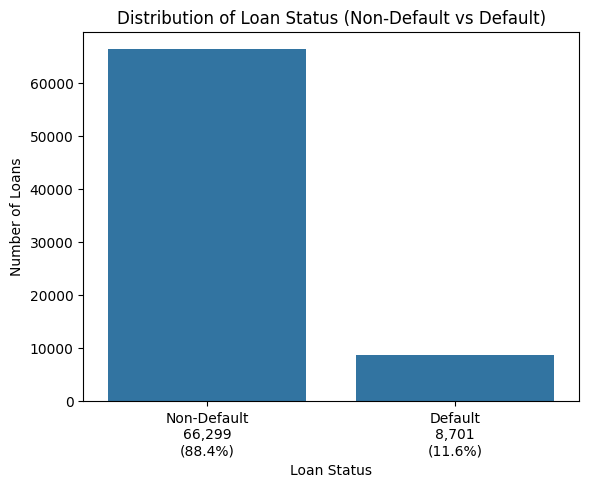

In [97]:
# Visualizing the distribution of the target variable (bad_status)
# to examine class imbalance between default and non-default loans
# 0 = Non-Default
# 1 = Default

import matplotlib.pyplot as plt
import seaborn as sns


counts = df_sample['bad_status'].value_counts().sort_index()
percentages = df_sample['bad_status'].value_counts(normalize=True).sort_index() * 100

labels = [
    f"Non-Default\n{counts[0]:,}\n({percentages[0]:.1f}%)",
    f"Default\n{counts[1]:,}\n({percentages[1]:.1f}%)"
]

ax = sns.countplot(x='bad_status', data=df_sample)

plt.xticks([0, 1], labels)
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.title('Distribution of Loan Status (Non-Default vs Default)')
plt.ticklabel_format(style='plain', axis='y')

plt.show()


The count plot illustrates the distribution of the target variable bad_status, which classifies loans as `non-default (0)` or `default (1`). The dataset is noticeably imbalanced, with non-default loans representing the majority of observations. Approximately 88.4% of loans fall into the non-default category, while about 11.6% are classified as default. This class imbalance is common in credit risk datasets and is important to consider during model development, as it may influence predictive performance and require techniques such as class weighting or resampling.

### 4.2 Correlation Analysis

In [98]:
# Selecting key features for correlation analysis 
# with the target variable (bad_status)
key_vars = [
    'bad_status',

    # Loan characteristics
    'loan_amnt',
    'int_rate',
    'installment',
    'term',

    # Borrower financial profile
    'annual_inc',
    'dti',

    # Credit quality
    'grade_combined',

    # Credit history
    'credit_history_years',
    'delinq_2yrs',

    # Credit utilization
    'revol_util',

    # Account information
    'open_acc',
    'total_acc',

    # Time features
    'loan_age_years'
]

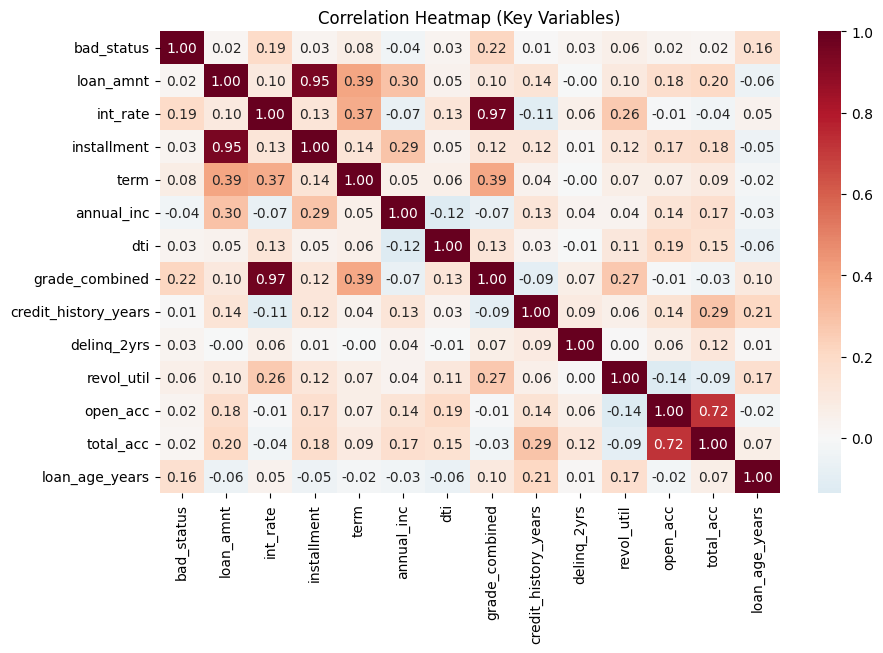

In [99]:
# Correlation heatmap of selected numerical variables
# used to examine relationships with the target variable

corr = df_sample[key_vars].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',   # better contrast (red vs blue)
    center=0,        # makes 0 neutral (white-ish)
    fmt=".2f"
)

plt.title('Correlation Heatmap (Key Variables)')
plt.show()

The correlation heatmap summarizes relationships among representative loan characteristics, borrower financial variables, credit history, and the target variable (`bad_status`). Among the selected features, `grade_combined` and `int_rate` exhibit the strongest positive correlations with loan default, indicating that borrowers with lower credit quality and higher interest rates are more likely to become delinquent. Most other variables show relatively weak individual correlations with the target, suggesting that no single predictor is sufficient to explain default risk. The heatmap also reveals strong correlations between several predictor variables, most notably `loan_amnt` and `installment`, `int_rate` and `grade_combined`, and `open_acc` and `total_acc`. These relationships indicate potential multicollinearity among some features, which should be considered during model development and interpretation.

### 4.3 Interest Rate Analysis

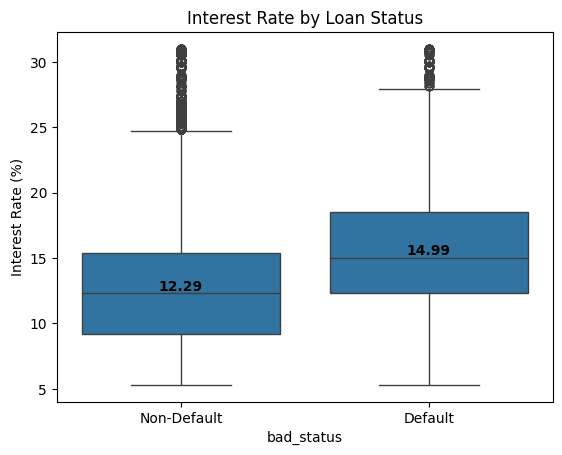

In [100]:
# Visualizing how interest rates differ between non-default and defaulted loans
# This helps assess whether borrowers with higher interest rates 
# are more likely to default

# Create the boxplot
sns.boxplot(x='bad_status', y='int_rate', data=df_sample)

# Calculate medians
medians = df_sample.groupby('bad_status')['int_rate'].median()

# Add median values to the plot
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Interest Rate (%)')
plt.title('Interest Rate by Loan Status')

plt.show()

The boxplot shows that delinquent loans tend to have higher interest rates than non-delinquent loans. The median interest rate is clearly higher, and the overall distribution is shifted upward. This suggests that higher borrowing costs may be associated with an increased likelihood of falling behind on payments.

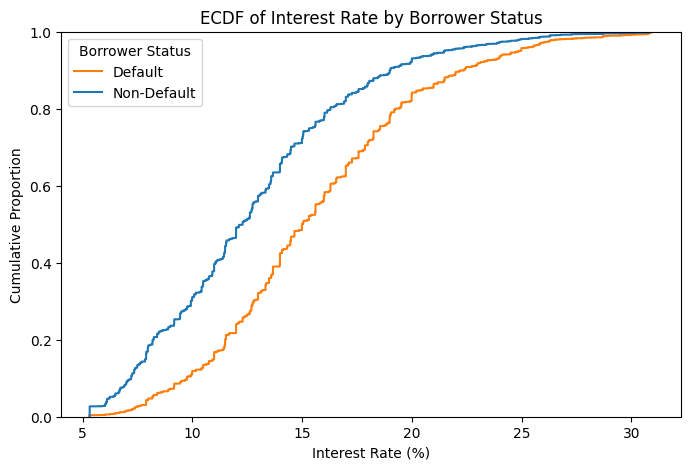

In [101]:
plt.figure(figsize=(8,5))

sns.ecdfplot(
    data=df_sample,
    x='int_rate',
    hue='bad_status'
)

plt.xlabel('Interest Rate (%)')
plt.ylabel('Cumulative Proportion')
plt.title('ECDF of Interest Rate by Borrower Status')

# Custom legend labels
plt.legend(
    labels=['Default', 'Non-Default'],
    title='Borrower Status'
)

plt.show()

This ECDF plot compares the distribution of interest rates between default and non-default borrowers. The default borrower distribution is shifted to the right, indicating that defaulted loans generally carry higher interest rates. In contrast, non-defaulted borrowers are more concentrated at lower interest rates. The visible separation between the two curves suggests that interest rate may be an important factor associated with borrower's delinquency and supports the earlier findings from the boxplot analysis.

### 4.4 Loan Grade (Combined) Analysis

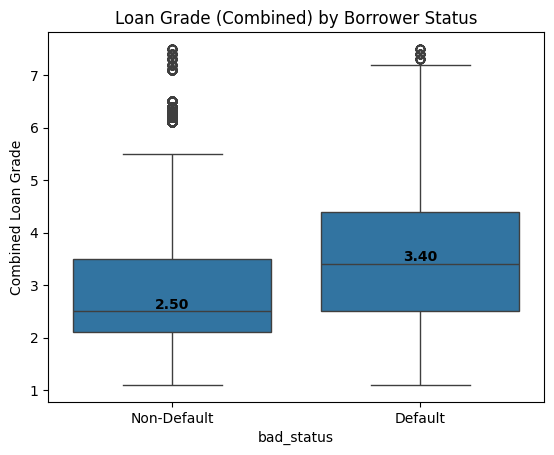

In [102]:
# Visualizing how loan grade differs between non-default and defaulted loans
# This helps evaluate whether lower credit quality 
# is associated with a higher risk of default

# Create the boxplot
sns.boxplot(x='bad_status', y='grade_combined', data=df_sample)

# Calculate medians
medians = df_sample.groupby('bad_status')['grade_combined'].median()

# Step 3: Add median values to the plot
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Combined Loan Grade')
plt.title('Loan Grade (Combined) by Borrower Status')
plt.show()

This plot shows how the combined loan grade differs between non-defaulted and defaulted loans.

The median combined grade for defaulted loans (3.40 –> C4) is higher than that of non-defaulted loans (2.50 –> B5), indicating that borrowers with weaker credit profiles are more likely to ultimately default on their loans.

The overall distribution of grades for defaulted loans is shifted toward lower credit quality, suggesting that poorer loan grades are associated with greater default risk.

However, there is considerable overlap between the two groups. Some higher-risk loans remain non-defaulted, indicating that while loan grade is an important predictor of default, it does not fully determine loan outcomes. Many borrowers with weaker credit profiles are still able to meet their repayment obligations.

### 4.5 Debt-to-Income (DTI) Analysis 

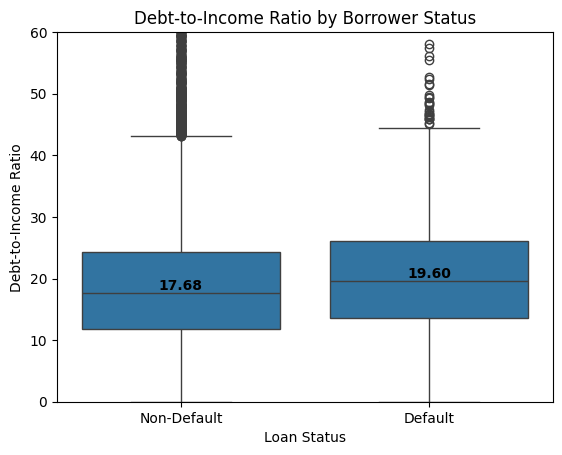

In [103]:
# Visualizing how DTI differs between non-default and defaulted loans
# The y-axis is limited because extreme outliers make the boxplot hard to read

sns.boxplot(x='bad_status', y='dti', data=df_sample)

# Calculate medians
medians = df_sample.groupby('bad_status')['dti'].median()

# Add median values
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Debt-to-Income Ratio')
plt.xlabel('Loan Status')
plt.title('Debt-to-Income Ratio by Borrower Status')

# Limit y-axis to make the main distribution visible
plt.ylim(0, 60)

plt.show()

The box plot comparing debt-to-income (DTI) ratios shows that defaulted loans tend to have slightly higher DTI values than non-defaulted loans. The median DTI ratio is higher among defaulted loans, suggesting that borrowers with greater debt relative to their income may face a higher risk of default. However, the difference between the two groups is relatively modest, indicating that DTI alone may not be a strong predictor of default. Extreme outliers are present in the data, and the y-axis was limited to better visualize the main distribution.

### 4.6 Annual Income Analysis

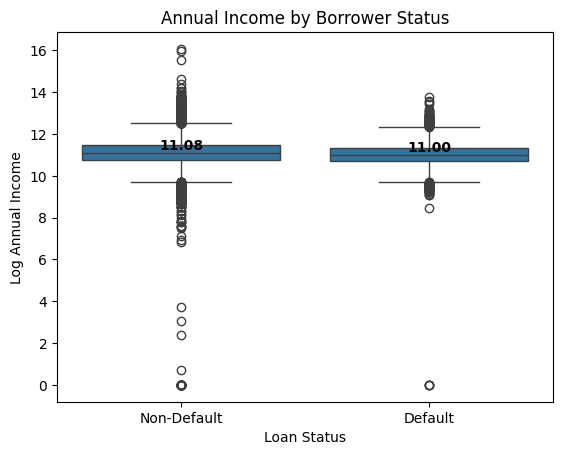

In [104]:
# Visualizing how annual income differs between non-default and defaulted loans
# Annual income is highly skewed, so log income is used to make the distribution easier to compare

df_sample['log_annual_inc'] = np.log1p(df_sample['annual_inc'])

sns.boxplot(x='bad_status', y='log_annual_inc', data=df_sample)

# Calculate medians
medians = df_sample.groupby('bad_status')['log_annual_inc'].median()

# Add median values
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Log Annual Income')
plt.xlabel('Loan Status')
plt.title('Annual Income by Borrower Status')

plt.show()

The distribution of annual income is very similar between defaulted and non-defaulted loans. Median income levels are nearly identical, and there is substantial overlap between the two groups. This suggests that annual income alone does not have a strong direct relationship with default risk in this dataset. Because of the presence of extreme values, a logarithmic transformation was applied to improve visualization; however, even after the transformation, the differences between the groups remain minimal.

Overall, interest rate and loan grade exhibit stronger relationships with default risk, while variables such as annual income and debt-to-income ratio (DTI) appear to provide weaker predictive signals on their own. These variables may still contribute valuable information when combined with other features in a predictive model.

### 4.7 Loan Purpose Distribution by Borrower Status

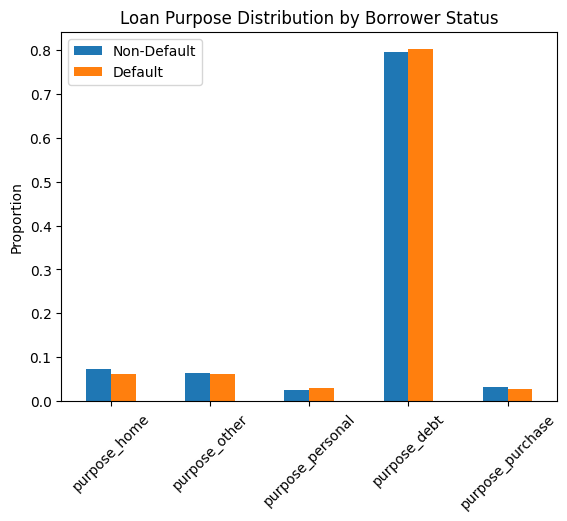

In [105]:
# Visualizing how loan purpose is associated with borrower delinquency
# Since loan purpose was one-hot encoded, we analyze the average proportion
# of each purpose category within delinquent and non-delinquent groups.
# This helps identify whether certain borrowing purposes are linked to higher risk.

purpose_cols = [
    'purpose_home',
    'purpose_other',
    'purpose_personal',
    'purpose_debt',
    'purpose_purchase'
]

# Calculate delinquency rate for each purpose
purpose_rates = df_sample.groupby('bad_status')[purpose_cols].mean().T

# Plot
purpose_rates.plot(kind='bar')
plt.title('Loan Purpose Distribution by Borrower Status')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(['Non-Default', 'Default'])
plt.show()

The distribution of loan purpose appears very similar between defaulted and non-defaulted borrowers. The majority of loans in both groups are associated with debt consolidation, and other categories show comparable proportions. This suggests that loan purpose does not have a strong relationship with default risk in this dataset.

### 5. Training Data Preparation

Before training the machine learning models, the dataset was prepared for predictive modeling. This stage included selecting the predictor and target variables, splitting the data into training and testing sets, and applying feature scaling where appropriate. These preprocessing steps help ensure that the models are trained on representative data and evaluated on unseen observations to provide an unbiased assessment of their predictive performance.

### 5.1 Feature and Target Selection
Before training the models, the dataset is split into two components. The first component, X, contains all of the information available about each loan, such as borrower characteristics and loan details. The second component, y, contains the target variable (bad_status), which tells the model whether each loan is classified as default or non-default. The goal of the model is to learn patterns in X that can accurately predict the values in y.

In [106]:
# Define the target variable (y)
# bad_status = 1 indicates a defaulted loan
# bad_status = 0 indicates a non-defaulted loan

y = df_sample['bad_status']

# Create the feature matrix (X)
# Remove the target variable so the model cannot use it to predict itself

X = df_sample.drop(columns=['bad_status'])

In [107]:
print(X.shape)
print(y.shape)

(75000, 76)
(75000,)


### 5.2 Train - Test Split

To evaluate how well the machine learning models generalize to unseen data, the dataset is divided into training and testing subsets. An 80/20 split is used, with **stratified** sampling to preserve the proportion of default and non-default loans in both sets. This helps ensure that the training and testing data remain representative of the original sample and allows for a fair evaluation of model performance.

In [108]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# The training set is used to train the model
# The testing set is used to evaluate how well the model performs on unseen data

# stratify=y preserves the original class distribution
# (approximately 80% non-default and 20% default) in both datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [109]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

bad_status
0    0.883983
1    0.116017
Name: proportion, dtype: float64
bad_status
0    0.884
1    0.116
Name: proportion, dtype: float64


In [110]:
X.isna().sum().sort_values(ascending=False).head(20)

loan_amnt              0
funded_amnt            0
funded_amnt_inv        0
term                   0
int_rate               0
installment            0
grade                  0
sub_grade              0
emp_length             0
annual_inc             0
verification_status    0
dti                    0
delinq_2yrs            0
inq_last_6mths         0
open_acc               0
pub_rec                0
revol_bal              0
revol_util             0
total_acc              0
initial_list_status    0
dtype: int64

### 5.3 Feature Scaling

Machine learning algorithms perform better when numerical features are measured on a similar scale. To account for differences in feature magnitude, the predictor variables are standardized using StandardScaler. The scaler is fitted only on the training data and then applied to both the training and testing sets, preventing information from the test data from influencing the training process and helping to avoid data leakage.

In [111]:
from sklearn.preprocessing import StandardScaler

# Standardize features before Logistic Regression

# Scaling transforms each feature so that:
# Mean = 0
# Standard Deviation = 1

# This prevents variables with larger numerical ranges
# from dominating variables with smaller ranges

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Modeling

This section presents the development and evaluation of several supervised machine learning models for predicting loan defaults. Logistic regression, random forest, and XGBoost classifiers were trained and compared using multiple performance metrics. Class imbalance was addressed using balancing techniques and SMOTE where appropriate, and hyperparameter tuning was performed to optimize model performance. The results were then compared to identify the model that provided the best overall balance between predictive accuracy and default detection.

### 6.1 Logistic Regression

Logistic Regression was selected as the baseline classification model because it is widely used in credit risk modeling, is easy to interpret, and provides a strong benchmark against which more complex machine learning models can be compared.

 #### **6.1.1 Baseline Logistic Regression**

In [112]:
# Baseline Logistic Regression

from sklearn.linear_model import LogisticRegression

# In this project:
# 1 = Default
# 0 = Non-Default

# Logistic Regression is widely used in credit risk modeling
# because it is interpretable and produces probability estimates

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

After training, the model was applied to the test dataset to generate predictions. The **predict()** function assigns each borrower to either the default or non-default class, while **predict_proba()** estimates the probability of default for each borrower. These probability estimates are later used to calculate the ROC-AUC score, which evaluates the model’s ability to distinguish between the two classes across different decision thresholds.

In [113]:
# Predict loan status for the test set

y_pred = logreg.predict(X_test_scaled)

# Predict probabilities of default
# These probabilities will later be used for ROC-AUC analysis

y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

In [114]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Classification metrics
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred))

# ROC-AUC Score
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     13260
           1       0.37      0.02      0.05      1740

    accuracy                           0.88     15000
   macro avg       0.63      0.51      0.49     15000
weighted avg       0.83      0.88      0.83     15000

Confusion Matrix
 [[13189    71]
 [ 1698    42]]
ROC-AUC: 0.7569823252024064


The baseline Logistic Regression model was evaluated using several classification metrics, including precision, recall, F1-score, the confusion matrix, and ROC-AUC. Although the overall accuracy reached 88%, accuracy alone is not an appropriate metric for this problem because the dataset is highly imbalanced, with approximately 88% non-default loans. A model that simply predicts every loan as non-default would achieve nearly the same accuracy while failing to identify borrowers who actually default.The recall of default cases is 2.4%, and an F1-score is 0.05, which suggests that the model is heavily biased toward predicting the majority class and performs poorly at detecting borrowers who are likely to default.

For imbalanced classification problems such as loan default prediction, greater emphasis is placed on precision, recall, and the F1-score. Recall measures how many actual defaults are successfully identified, while precision measures how many predicted defaults are truly defaults. The F1-score combines both metrics into a single measure, providing a better indication of model performance when the classes are unevenly distributed.

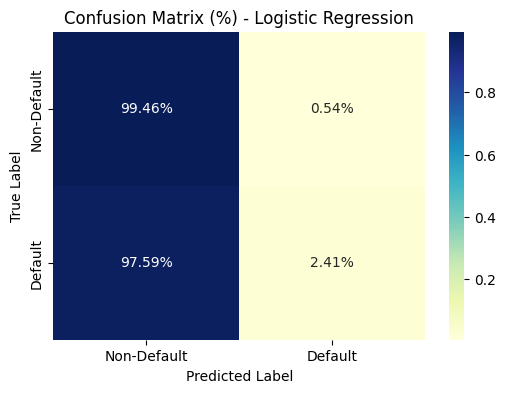

In [115]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm_percent = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2%',
    cmap='YlGnBu',
    xticklabels=['Non-Default', 'Default'],
    yticklabels=['Non-Default', 'Default']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (%) - Logistic Regression')

plt.show()

The confusion matrix further illustrates the limitations of the baseline model. Nearly all non-default loans (99.46%) were correctly classified, while only 2.41% of actual default loans were correctly identified. Approximately 97.6% of defaulting borrowers were incorrectly classified as non-default, demonstrating that the model largely ignores the minority class. This behavior is common when training logistic regression on an imbalanced dataset without applying techniques such as class weighting or resampling.

#### **6.1.2 Balanced Logistic Regression**

Balanced Logistic Regression applies class weights (`class_weight = 'balanced'`) to compensate for the imbalanced distribution of the target variable. It assigns higher weights to the minority class (default loans) and lower weights to the majority class (non-default loans). This encourages the model to pay more attention to default cases and improves its ability to detect them. 

In [116]:
# Balanced Logistic Regression with Ridge

from sklearn.linear_model import LogisticRegression

logreg_balanced = LogisticRegression(
    class_weight='balanced',
    penalty = 'l2',
    max_iter=1000,
    random_state=42
)

logreg_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [117]:
y_pred_balanced = logreg_balanced.predict(X_test_scaled)

y_pred_proba_balanced = logreg_balanced.predict_proba(X_test_scaled)[:,1]

In [118]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_proba_balanced)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7591757684506163


In [119]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.94      0.70      0.80     13260
           1       0.23      0.68      0.34      1740

    accuracy                           0.70     15000
   macro avg       0.59      0.69      0.57     15000
weighted avg       0.86      0.70      0.75     15000



In [120]:
from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
print("Confusion Matrix:\n", cm_balanced)

Confusion Matrix:
 [[9252 4008]
 [ 556 1184]]


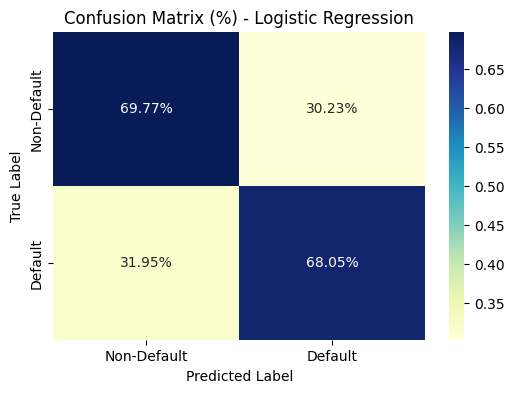

In [121]:
# Visualization of confusion matrix in %

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_balanced)
cm_percent = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2%',
    cmap='YlGnBu',
    xticklabels=['Non-Default', 'Default'],
    yticklabels=['Non-Default', 'Default']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (%) - Logistic Regression')

plt.show()

The balanced Logistic Regression model achieved an accuracy of 70%, a recall of 68% and a precision of 23% for the default class, with a ROC-AUC score of 0.759. Although the overall accuracy decreased from 88% to 70%, the balanced model substantially improved its ability to identify borrowers who eventually defaulted. This trade-off is expected when addressing class imbalance, as the model becomes more sensitive to the minority class at the expense of increased false positive predictions. The ROC-AUC score indicates that the model maintained a moderate ability to distinguish between default and non-default borrowers. By default, Logistic Regression uses L2 (Ridge) regularization, which helps reduce overfitting by shrinking model coefficients while retaining all predictor variables.

#### **6.1.3 Balanced Logisic Regression with Lasso**

Next, the balanced Logistic Regression model was trained using L1 (Lasso) regularization instead of L2 (Ridge). While Ridge shrinks all coefficients toward zero, Lasso can shrink some coefficients to exactly zero, effectively performing feature selection. This comparison helps evaluate whether a different regularization method improves model performance.

In [122]:
# Balanced Logistic Regression with Lasso

lasso_logreg = LogisticRegression(
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lasso_logreg.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='saga')

In [123]:
y_pred_lasso = lasso_logreg.predict(X_test_scaled)

y_pred_proba_lasso = lasso_logreg.predict_proba(X_test_scaled)[:,1]

In [124]:
# Print classification report and ROC-AUC
print(classification_report(y_test, y_pred_lasso))
roc_auc = roc_auc_score(y_test, y_pred_proba_lasso)
print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.94      0.70      0.80     13260
           1       0.23      0.68      0.34      1740

    accuracy                           0.70     15000
   macro avg       0.59      0.69      0.57     15000
weighted avg       0.86      0.70      0.75     15000

ROC-AUC: 0.7591467294256341


The Lasso-regularized model produced identical performance to the Ridge model across all evaluation metrics. This means that changing the regularization method had no impact on predictive performance for this dataset; both approaches performed similarly.

#### **6.1.4 Logistic Regression with SMOTE Oversampling**

As an alternative approach to handling class imbalance, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data before fitting the Logistic Regression model. Unlike class weighting, SMOTE generates synthetic examples of the minority class to create a more balanced training dataset. The model’s performance was then compared with the previous class-weighted Logistic Regression models.

In [125]:
# ==============================
# SMOTE + Logistic Regression
# ==============================

# Import SMOTE
from imblearn.over_sampling import SMOTE

# Import scaler and model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [126]:
# Apply SMOTE ONLY to the training data
# Do NOT apply SMOTE to X_test or y_test

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [127]:
# Check class balance before SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
bad_status
0    53039
1     6961
Name: count, dtype: int64


In [128]:
# Check class balance after SMOTE

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
bad_status
1    53039
0    53039
Name: count, dtype: int64


In [129]:
# Scale the SMOTE training data
# Fit the scaler on X_train_smote only
# Transform X_test using the same scaler

scaler_smote = StandardScaler()

X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_smote_scaled = scaler_smote.transform(X_test)

In [130]:
# Create Logistic Regression model
# No class_weight='balanced' here because SMOTE already balanced the training data

lr_smote = LogisticRegression(
    penalty='l2',
    max_iter=5000,
    random_state=42
)

In [131]:
# Train the model on the SMOTE-balanced, scaled training data

lr_smote.fit(X_train_smote_scaled, y_train_smote)

LogisticRegression(max_iter=5000, random_state=42)

In [132]:
# Make predictions on the original test set, scaled with the SMOTE scaler

y_pred_smote = lr_smote.predict(X_test_smote_scaled)

y_pred_proba_smote = lr_smote.predict_proba(X_test_smote_scaled)[:, 1]

In [133]:
# Evaluate the model

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93     13260
           1       0.31      0.10      0.15      1740

    accuracy                           0.87     15000
   macro avg       0.60      0.54      0.54     15000
weighted avg       0.82      0.87      0.84     15000



In [134]:
# Confusion matrix

cm_smote = confusion_matrix(y_test, y_pred_smote)

print("Confusion Matrix:\n", cm_smote)

Confusion Matrix:
 [[12878   382]
 [ 1567   173]]


In [135]:
# ROC-AUC score

roc_auc_smote = roc_auc_score(y_test, y_pred_proba_smote)

print("SMOTE Logistic Regression ROC-AUC:", roc_auc_smote)

SMOTE Logistic Regression ROC-AUC: 0.723306374716111


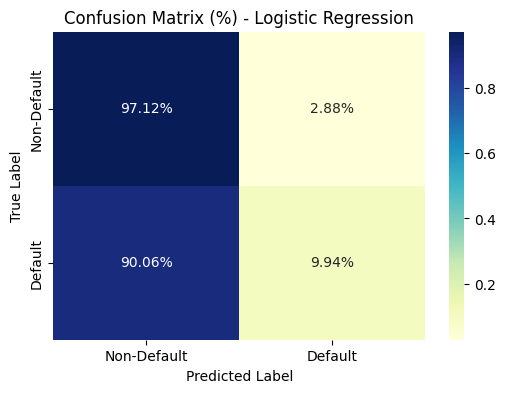

In [136]:
# Visualization of confusion matrix in %

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_smote = confusion_matrix(y_test, y_pred_smote)
cm_percent = cm_smote / cm_smote.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2%',
    cmap='YlGnBu',
    xticklabels=['Non-Default', 'Default'],
    yticklabels=['Non-Default', 'Default']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (%) - Logistic Regression')

plt.show()

The Logistic Regression model trained using SMOTE achieved an overall accuracy of 87%, a precision of 31% and a recall of 10% for the default class, with a ROC-AUC score of 0.723. Although the overall accuracy and precision for the default class improved compared with the class-weighted model, the recall dropped substantially from 68% to 10%, indicating that the model identified far fewer defaulting borrowers. As a result, the F1-score for the default class also decreased from 0.34 to 0.15, reflecting the weaker balance between precision and recall. In contrast, the model performed very well on the majority (non-default) class, achieving 89% precision, 97% recall, and an F1-score of 0.93.

### **Conclusion**:
Among the Logistic Regression models evaluated, the balanced Logistic Regression with class weighting produced the strongest overall performance. Although SMOTE increased overall accuracy, it substantially reduced recall for the default class, making it less effective at identifying defaulting borrowers. Therefore, the class-weighted Logistic Regression was selected as the preferred Logistic Regression model for this dataset.

#### **6.1.5 Hyperparameter Tuning for Logistic Regression**

To further optimize model performance, GridSearchCV with 5-fold cross-validation is going to be used identify the optimal hyperparameter values for the Logistic Regression model.

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    solver='liblinear'
)

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.01}
0.6815117252931323


'C' is the inverse of regularization strength. The simplest model (C = 0.01) generalized the best.


In [138]:
best_logreg = grid.best_estimator_

y_pred = best_logreg.predict(X_test_scaled)
y_proba = best_logreg.predict_proba(X_test_scaled)[:, 1]

In [139]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

best_logreg = grid.best_estimator_

y_pred = best_logreg.predict(X_test_scaled)
y_proba = best_logreg.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
[[9163 4097]
 [ 546 1194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.69      0.80     13260
           1       0.23      0.69      0.34      1740

    accuracy                           0.69     15000
   macro avg       0.58      0.69      0.57     15000
weighted avg       0.86      0.69      0.74     15000

ROC-AUC: 0.7578584802621314


### **Analysis and Conclusion:**

Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation to identify the optimal value of the regularization parameter (C). The model selected **C = 0.01**, indicating that stronger regularization provided the best cross-validation performance. The average cross-validation **recall** was **68.2%**. When evaluated on the test set, the tuned model achieved **69% accuracy**, **69% recall** for the default class, and a **ROC-AUC** of **0.758**, producing results that were nearly identical to the original balanced logistic regression. Therefore, hyperparameter tuning did not provide a meaningful improvement in predictive performance.
Among all Logistic Regression variants evaluated, the balanced Logistic Regression model provided the best overall trade-off between identifying default borrowers and maintaining overall predictive performance.

### 6.2 Random Forest


It is an ensemble classification algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. It has an ability to capture nonlinear relationships and feature interactions and makes it well suited for predicting loan default.
The Random Forest model is evaluated to determine whether a more flexible, nonlinear algorithm can improve the prediction of loan defaults compared with logistic regression.

#### **6.2.1 Baseline Random Forest**

In [140]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     13260
           1       0.50      0.00      0.01      1740

    accuracy                           0.88     15000
   macro avg       0.69      0.50      0.47     15000
weighted avg       0.84      0.88      0.83     15000



The baseline Random Forest achieved an overall accuracy of 88%, but it failed to effectively identify the minority default class. While nearly all non-default loans were classified correctly, the model failed to detect actual defaults, resulting in a near-zero recall for the default class. This demonstrates that, despite its high accuracy, the baseline Random Forest is heavily biased toward the majority class and is not suitable for identifying loan defaults.

In [141]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_test)

print(classification_report(y_test, y_pred_rf_balanced))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     13260
           1       0.44      0.00      0.01      1740

    accuracy                           0.88     15000
   macro avg       0.66      0.50      0.47     15000
weighted avg       0.83      0.88      0.83     15000



Applying `class_weight='balanced'` did not produce a meaningful improvement. The model continued to classify nearly all observations as non-default, with default recall remaining close to zero. This suggests that class weighting alone was insufficient to overcome the class imbalance, indicating that additional techniques such as hyperparameter tuning or resampling would be necessary.

#### **6.2.2 Random Forest with SMOTE Oversampling**

In [142]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)

print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93     13260
           1       0.35      0.07      0.12      1740

    accuracy                           0.88     15000
   macro avg       0.62      0.53      0.53     15000
weighted avg       0.83      0.88      0.84     15000



Applying SMOTE before training the Random Forest produced a slight improvement over the baseline and class-weighted models. The default class recall increased from nearly 0% to 7%, indicating that the model identified more default cases. However, the improvement remained limited, and the model continued to favor the majority class, achieving high performance for non-default loans but poor detection of defaults. Compared with the balanced logistic regression model, the Random Forest with SMOTE performed substantially worse on the minority class.

#### **6.2.3 Hyperparameter Tuning for Random Forest**

In [143]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


param_grid = {
    "criterion": ["gini", "entropy"],
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_leaf": [5, 10],
    "max_features": ["sqrt"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV recall:", rf_grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 50}
Best CV recall: 0.7256127214290312


In [144]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Confusion Matrix:
 [[8601 4659]
 [ 467 1273]]
              precision    recall  f1-score   support

           0       0.95      0.65      0.77     13260
           1       0.21      0.73      0.33      1740

    accuracy                           0.66     15000
   macro avg       0.58      0.69      0.55     15000
weighted avg       0.86      0.66      0.72     15000

ROC-AUC: 0.758212691354172


### **Conclusion:**
Hyperparameter tuning was performed using GridSearchCV with 3-fold cross-validation, optimizing for recall. The search evaluated different combinations of hyperparameters, including the splitting criterion (gini impurity vs entropy), maximum tree depth, number of estimators, maximum features, and minimum samples per leaf. The best-performing model used the entropy criterion, a maximum depth of 5, 50 trees, max_features='sqrt', and min_samples_leaf=10, achieving a **cross-validation recall** of **0.726**. On the test set, the tuned model achieved a **recall** of **0.73** for the default class, an overall **accuracy** of **0.66**, and a **ROC-AUC** score of **0.758**. While the tuned random forest improved the identification of defaulted loans, it did so at the expense of lower recall for the non-default class. Overall, the balanced logistic regression remained the preferred model, providing a more balanced trade-off between identifying defaults and maintaining strong performance across both classes while achieving a comparable ROC-AUC.

#### **6.3 Extreme Gradient Boosting (XGBoost)**


XGBoost is an ensemble machine learning algorithm based on gradient boosting. Unlike Random Forest, which builds many independent decision trees in parallel, XGBoost builds trees sequentially, with each new tree focusing on correcting the errors made by the previous ones. It is widely used because it often achieves excellent predictive performance while handling complex, non-linear relationships. In this project, XGBoost was evaluated as an additional classification model to determine whether it could improve the prediction of loan defaults compared to logistic regression and random forest.

#### **6.3.1 Baseline XGBoost**

In [145]:
from xgboost import XGBClassifier
!pip install xgboost

In [146]:
# Calculate the class imbalance ratio to give more weight to the minority (default) class
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [147]:
# Initialize the XGBoost classifier with parameters for imbalanced classification

xgb = XGBClassifier(n_estimators=200,      # Number of boosting trees
                    max_depth=6,           # Maximum depth of each tree
                    learning_rate=0.05,    # Controls how quickly the model learns
                    scale_pos_weight=scale_pos_weight,  # Increase weight of the minority class
                    random_state=42,       # Ensures reproducible results
                    eval_metric='logloss'  # Evaluation metric during training
                   )

In [148]:
y_train.value_counts()

bad_status
0    53039
1     6961
Name: count, dtype: int64

In [149]:
# Train the XGBoost model on the training data
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [150]:
# Make predictions
y_pred_xgb = xgb.predict(X_test)

y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

In [151]:
# Print classification report and ROC-AUC
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

print(classification_report(y_test, y_pred_xgb))


print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))

              precision    recall  f1-score   support

           0       0.95      0.68      0.80     13260
           1       0.23      0.71      0.35      1740

    accuracy                           0.69     15000
   macro avg       0.59      0.70      0.57     15000
weighted avg       0.86      0.69      0.74     15000

ROC-AUC: 0.7716763752362128


Multiple classification approaches were evaluated, including Logistic Regression, Random Forest, and XGBoost. XGBoost achieved the highest ROC-AUC (0.772), indicating the strongest overall ability to distinguish between default and non-default loans. However, the balanced logistic regression remained highly competitive, providing similar recall with greater interpretability. These results suggest that while ensemble methods offer modest improvements in predictive performance, borrower characteristics provide only moderate predictive signal, limiting the gains achieved by increasingly complex models.

#### **6.3.2 Hyperparameter Tuning for XGBoost**

Hyperparameter tuning was performed using RandomizedSearchCV with 3-fold cross-validation to identify an improved XGBoost model. Randomized search was selected because it efficiently evaluates a random subset of hyperparameter combinations while exploring a broad search space. The tuning process optimized the number of trees, tree depth, learning rate, minimum child weight, gamma, subsampling ratio, and feature sampling ratio. Model performance was evaluated using recall, F1-score, and ROC-AUC, with the final model selected based on the highest cross-validated F1-score to achieve a balanced trade-off between identifying defaulted loans and minimizing false positives.

In [152]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# Calculate class imbalance ratio from the training data
# This gives more weight to the minority class: default loans
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# Initialize baseline XGBoost classifier
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# Define hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0, 0.1, 0.3, 0.5]
}

# Evaluate several metrics during cross-validation
# refit='f1' means the final best model is selected based on F1 score
scoring = {
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# RandomizedSearchCV tests a random sample of hyperparameter combinations
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring=scoring,
    refit='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the randomized search on the training data
xgb_random.fit(X_train, y_train)

# Print best parameters and best cross-validation F1 score
print("Best parameters:", xgb_random.best_params_)
print("Best CV F1:", xgb_random.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best parameters: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.9}
Best CV F1: 0.3452608825116259


In [153]:
# Converting CV results to a DataFrame for easier comparison
xgb_results = pd.DataFrame(xgb_random.cv_results_)

# Show the top parameter combinations ranked by F1 score
xgb_results[
    ['mean_test_recall', 'mean_test_f1', 'mean_test_roc_auc', 'params']
].sort_values(by='mean_test_f1', ascending=False).head()

,mean_test_recall,mean_test_f1,mean_test_roc_auc,params
6,0.623617,0.345261,0.761135,"{'subsample': 0.7, 'n_estimators': 500, 'min_c..."
13,0.676195,0.343187,0.765697,"{'subsample': 0.9, 'n_estimators': 300, 'min_c..."
24,0.685964,0.341376,0.764926,"{'subsample': 1.0, 'n_estimators': 300, 'min_c..."
20,0.705933,0.340364,0.766876,"{'subsample': 0.8, 'n_estimators': 200, 'min_c..."
17,0.698463,0.339510,0.764791,"{'subsample': 1.0, 'n_estimators': 200, 'min_c..."


In [154]:
# Extract the best tuned XGBoost model
best_xgb = xgb_random.best_estimator_

# Make predictions on the test set
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

# Evaluate model performance
print("Tuned XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print("\nTuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

print("Tuned XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_tuned))

Tuned XGBoost Confusion Matrix:
[[9485 3775]
 [ 573 1167]]

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.72      0.81     13260
           1       0.24      0.67      0.35      1740

    accuracy                           0.71     15000
   macro avg       0.59      0.69      0.58     15000
weighted avg       0.86      0.71      0.76     15000

Tuned XGBoost ROC-AUC: 0.7698058502799882


#### **Conclusion:**
The tuned XGBoost model achieved an accuracy of 71%, a recall of 72% for the non-default class and 67% for the default class, with a ROC-AUC score of 0.770. Compared with the balanced logistic regression, the tuned XGBoost model provided modest improvements in overall accuracy, non-default recall, and ROC-AUC, while maintaining comparable performance in identifying defaulted loans. These findings suggest that hyperparameter tuning slightly improved the model’s overall predictive performance, although the gains over the balanced logistic regression were relatively small.

## 7. Model Comparison


Multiple machine learning models and modeling approaches were developed, evaluated, and refined throughout this project to predict loan defaults. This section compares the best-performing version of each model using key evaluation metrics to identify the approach that provides the best overall balance between predictive performance and interpretability.

### 7.1 Performance Summary of the Four Best Models

In [155]:
import pandas as pd
import numpy as np

# Enter the best results for each model
model_comparison = pd.DataFrame({
    'Model': [
        'Balanced Logistic Regression',
        'Tuned Logistic Regression',
        'Tuned Random Forest',
        'Tuned XGBoost'
    ],
    
    'Accuracy': [
        0.70,   # balanced LR accuracy
        0.69,   # tuned Logistic Regression accuracy
        0.66,   # Tuned Random Forest accuracy
        0.71    # Tuned XGBoost accuracy
    ],
    
    'Recall: Non-Default (Class 0)': [
        0.70,   # balanced LR
        0.69,   # tuned Logistic Regression class 0 recall
        0.65,   # tuned RF
        0.72    # tuned XGBoost
    ],
    
    'Recall: Default (Class 1)': [
        0.68,
        0.69,   # tuned Logistic Regression class 1 recall
        0.73,
        0.67
    ],
    
    'F1-Score: Default (Class 1)': [
        0.34,   # balanced Logistic Regression class 1 F1
        0.34,   # tuned Logistic Regression class 1 F1
        0.33,   # tuned RF class 1 F1
        0.35    # tuned XGBoost class 1 F1
    ],
    
    'ROC-AUC': [
        0.759,
        0.758,   # tuned Logistic Regression ROC-AUC
        0.758,   # tuned RF
        0.770    # tuned XGBoost
    ]
})

model_comparison

,Model,Accuracy,Recall: Non-Default (Class 0),Recall: Default (Class 1),F1-Score: Default (Class 1),ROC-AUC
0,Balanced Logistic Regression,0.70,0.70,0.68,0.34,0.759
1,Tuned Logistic Regression,0.69,0.69,0.69,0.34,0.758
2,Tuned Random Forest,0.66,0.65,0.73,0.33,0.758
3,Tuned XGBoost,0.71,0.72,0.67,0.35,0.770


In [156]:
# Create a polished model comparison table

metric_columns = [
    "Accuracy",
    "Recall: Non-Default (Class 0)",
    "Recall: Default (Class 1)",
    "F1-Score: Default (Class 1)",
    "ROC-AUC"
]

styled_table = (
    model_comparison.style
    .format({
        "Accuracy": "{:.1%}",
        "Recall: Non-Default (Class 0)": "{:.1%}",
        "Recall: Default (Class 1)": "{:.1%}",
        "F1-Score: Default (Class 1)": "{:.1%}",
        "ROC-AUC": "{:.1%}"
    })
    .background_gradient(
        subset=["Accuracy"],
        cmap="Blues"
    )
    .background_gradient(
        subset=["Recall: Non-Default (Class 0)"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["Recall: Default (Class 1)"],
        cmap="Oranges"
    )
    .background_gradient(
        subset=["F1-Score: Default (Class 1)"],
        cmap="Purples"
    )
    .background_gradient(
        subset=["ROC-AUC"],
        cmap="YlGnBu"
    )
    .highlight_max(
        subset=metric_columns,
        props="font-weight: bold; border: 2px solid black;"
    )
    .set_caption("Comparison of Best-Performing Classification Models")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "12px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#37474F"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid white")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid #dddddd")
            ]
        },
        {
            "selector": "td:first-child",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold"),
                ("white-space", "nowrap")
            ]
        }
    ])
    .hide(axis="index")
)

display(styled_table)

Model,Accuracy,Recall: Non-Default (Class 0),Recall: Default (Class 1),F1-Score: Default (Class 1),ROC-AUC
Balanced Logistic Regression,70.0%,70.0%,68.0%,34.0%,75.9%
Tuned Logistic Regression,69.0%,69.0%,69.0%,34.0%,75.8%
Tuned Random Forest,66.0%,65.0%,73.0%,33.0%,75.8%
Tuned XGBoost,71.0%,72.0%,67.0%,35.0%,77.0%


### ***Analysis:***

The performance comparison highlights the trade-offs among the four best-performing classification models. No single model achieved the highest score across every evaluation metric, making it important to consider the overall balance between identifying defaulted loans (true positives) and correctly classifying non-defaulted borrowers (true negatives).

### **Key Observations:**

- **Tuned Random Forest** achieved **the highest recall for the default class (73%)**, meaning it identified the largest proportion of borrowers who eventually defaulted (true positives). However, this improvement came at the expense of lower performance on non-defaulted loans, with a recall of only **65%** (true negatives), and **the lowest overall accuracy (66%)** among the models. This indicates that the model incorrectly classified more non-defaulted borrowers as defaults, increasing the number of false positives.
- **Balanced Logistic Regression** produced a balanced overall performance. It achieved **70% accuracy**, **70% recall for non-defaulted loans, and 68% recall for defaulted loans**, while maintaining a competitive **ROC-AUC of 0.759**. Although it did not achieve the highest score in any single metric, its performance remained consistently strong across all evaluation measures. In addition, logistic regression offers greater interpretability, making it easier to explain how individual borrower characteristics influence the predicted probability of default.
- **Hyperparameter-Tuned Logistic Regression** produced results that were very similar to the balanced logistic regression, indicating that hyperparameter tuning provided only limited improvement for this dataset.
- **Tuned XGBoost** delivered **the strongest overall predictive performance**. It achieved the **highest overall accuracy (71%)**, the **highest recall for the non-default class (72%)**, the **highest F1-score for the default class (35%)**, and the **highest ROC-AUC (0.770)**. Although its **recall for the default class (67%)** was slightly lower than that of the **balanced logistic regression (68%)** and **tuned Random Forest (73%)**, it provided the best overall balance across all evaluation metrics.

### **Final Model Selection**

- Overall, the **tuned XGBoost model** was selected as the final model because it consistently achieved the strongest overall predictive performance while maintaining competitive default detection. The improvement over the balanced logistic regression was modest—generally around 1 percentage point across the key evaluation metrics—but it demonstrated a slightly better ability to distinguish between defaulted and non-defaulted loans.

- However, the **balanced logistic regression** remained a highly competitive alternative. Despite its slightly lower overall performance, it achieved nearly identical results while offering substantial advantages in model simplicity, interpretability, and computational efficiency. For applications where model transparency is a priority, balanced logistic regression would represent a practical and well-justified choice.

- Ultimately, the choice between the two models depends on the lender’s objectives and the desired balance between identifying defaulted borrowers and minimizing false positive predictions. Under different lending strategies and risk tolerances, either model could be an appropriate choice.



### 7.2 ROC Curve Comparison

In [157]:
# Balanced Logistic Regression
y_pred_proba_balanced

# Tuned Logistic Regression
y_proba

# Tuned Random Forest
y_proba_rf

# Tuned XGBoost
y_proba_xgb_tuned

array([0.070492  , 0.6609148 , 0.38766685, ..., 0.6588258 , 0.27344182,
       0.6873801 ], shape=(15000,), dtype=float32)

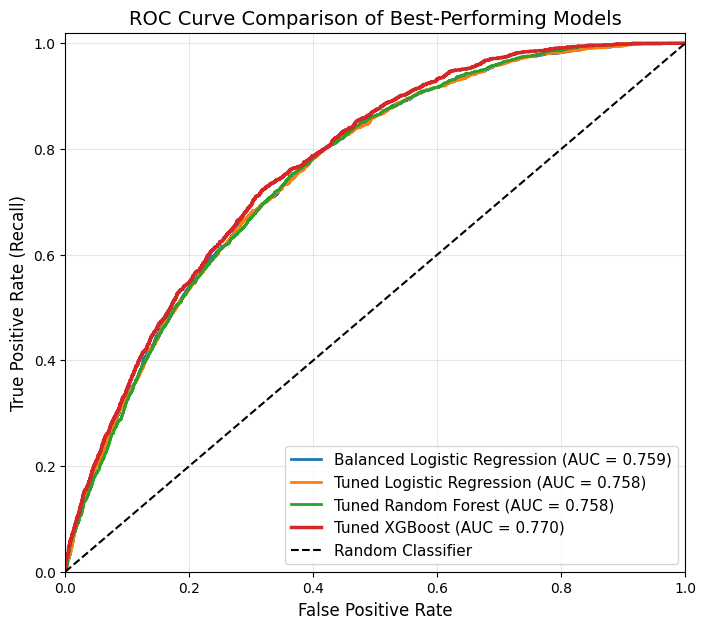

In [158]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC curves
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_pred_proba_balanced)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb_tuned)

plt.figure(figsize=(8,7))

plt.plot(
    fpr_bal,
    tpr_bal,
    linewidth=2,
    label=f'Balanced Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_balanced):.3f})'
)

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f'Tuned Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Tuned Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2.5,
    label=f'Tuned XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb_tuned):.3f})'
)

# Random classifier
plt.plot([0,1],[0,1],'k--',linewidth=1.5,label='Random Classifier')

plt.xlim([0,1])
plt.ylim([0,1.02])

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curve Comparison of Best-Performing Models", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(loc="lower right", fontsize = 11)

plt.show()

The above plot compares the ROC curves of all of the four best-performing classification models. Every curve lies well above the diagonal line, which means all models demonstrate good discriminatory ability, with ROC-AUC values ranging from 0.758 to 0.770. The curves almost overlap, indicating similar performance in distinguishing defaulted from non-defaulted loans. The tuned XGBoost model consistently stys just above the others with he highest ROC-AUC (0.770). However, the performance differences between the models are relatively small.

### 7.3 Top 20 Important Features

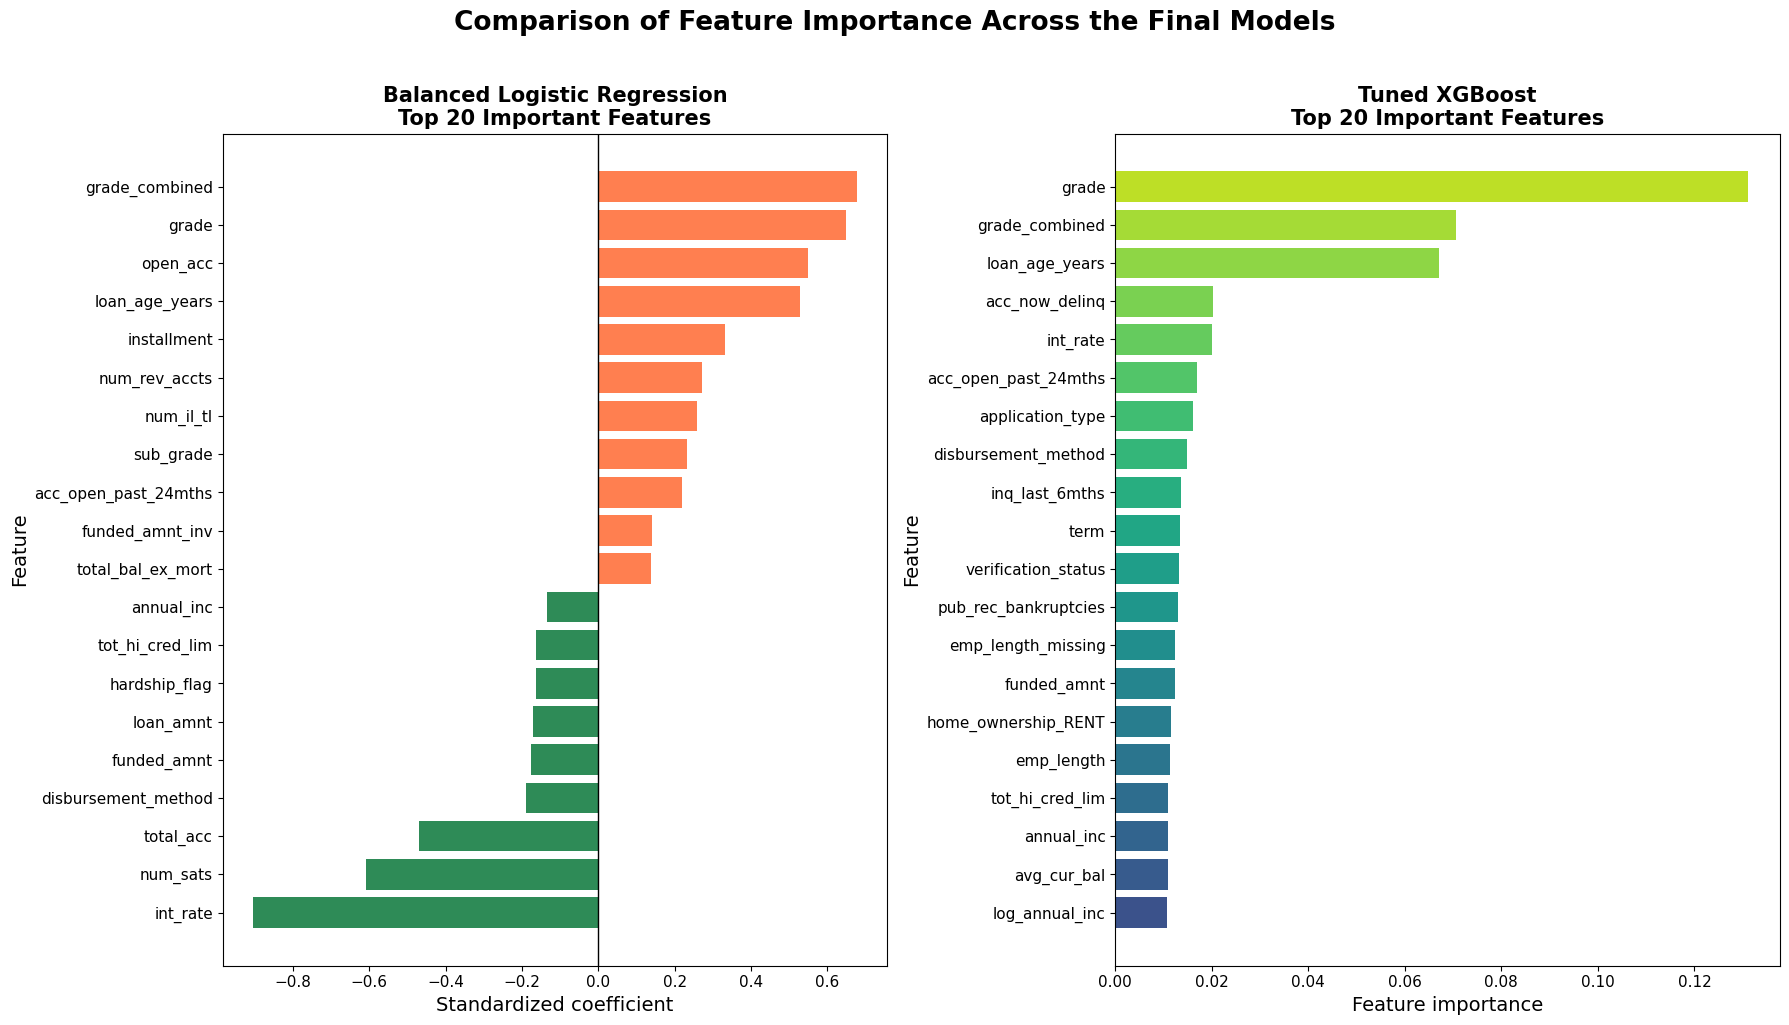

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the feature names from the training dataset
feature_names = X_train.columns

# ---------------------------------------------------------
# Balanced Logistic Regression coefficients
# ---------------------------------------------------------

lr_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logreg_balanced.coef_[0]
})

# Select the 20 largest coefficients by absolute magnitude
top_lr = (
    lr_coefficients
    .assign(Absolute_Coefficient=lambda x: x["Coefficient"].abs())
    .nlargest(20, "Absolute_Coefficient")
    .sort_values("Coefficient")
)

# ---------------------------------------------------------
# Tuned XGBoost feature importance
# ---------------------------------------------------------

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb.feature_importances_
})

top_xgb = (
    xgb_importance
    .nlargest(20, "Importance")
    .sort_values("Importance")
)

# ---------------------------------------------------------
# 3. Plot both analyses side by side
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Logistic Regression coefficients
lr_colors = [
    "seagreen" if value < 0 else "coral"
    for value in top_lr["Coefficient"]
]

axes[0].barh(
    top_lr["Feature"],
    top_lr["Coefficient"],
    color=lr_colors
)

axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(
    "Balanced Logistic Regression\nTop 20 Important Features",
    fontsize=15,
    fontweight="bold"
)
axes[0].set_xlabel("Standardized coefficient", fontsize=14)
axes[0].set_ylabel("Feature", fontsize = 14)
axes[0].tick_params(axis='x', labelsize=11)
axes[0].tick_params(axis='y', labelsize=11)

# XGBoost importance
axes[1].barh(
    top_xgb["Feature"],
    top_xgb["Importance"],
    color=plt.cm.viridis(
        np.linspace(0.25, 0.90, len(top_xgb))
    )
)

axes[1].set_title(
    "Tuned XGBoost\nTop 20 Important Features",
    fontsize=15,
    fontweight="bold"
)
axes[1].set_xlabel("Feature importance", fontsize = 14)
axes[1].set_ylabel("Feature", fontsize = 14)
axes[1].tick_params(axis='x', labelsize=11)
axes[1].tick_params(axis='y', labelsize=11)

fig.suptitle(
    "Comparison of Feature Importance Across the Final Models",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

**Note**: 
- For the Balanced Logistic Regression model, feature rankings are based on the absolute values of the standardized model coefficients. Positive coefficients indicate that higher values of a feature increase the predicted probability of loan default, whereas negative coefficients indicate that higher values decrease the predicted probability of default.

- The negative coefficient observed for interest_rate should not be interpreted as evidence that higher interest rates reduce default risk. Interest rate is highly correlated with the combined credit grade (correlation ≈ 0.97), resulting in multicollinearity. Because both variables capture very similar information, the logistic regression coefficients become unstable and may change sign despite the underlying positive relationship between interest rates and default risk.

- For the tuned XGBoost model, feature importance scores measure each feature’s contribution to the model’s predictions but do not indicate whether the relationship with default risk is positive or negative.

### ***Key Observations:***

- **Loan grade** was the most influential predictor across both models. Since loan grades are assigned using multiple borrower characteristics and are closely related to the interest rate assigned to a loan, they capture much of the underlying credit risk used by both models.

- While both models identified loan grade and loan age as important predictors, they differed in the remaining features they emphasized. Logistic Regression assigned greater importance to variables with strong linear relationships, whereas XGBoost identified additional variables that may contribute through more complex interactions.

- The Balanced Logistic Regression model provides interpretable coefficients that indicate whether a feature increases or decreases the predicted probability of default. In contrast, XGBoost feature importance scores indicate only the relative contribution of each feature to the model’s predictions and do not provide the direction of the relationship.

## 8. Conclusions and Recommendations

### 8.1 Summary and Findings

The objective of this project was to develop a machine learning model capable of accurately predicting loan defaults using LendingClub loan data. Since the dataset was highly imbalanced (with an approx. 88.4% loans in the non-default category), there were multiple strategies applied to improve the detection of defaulted loans.

**Logistic Regression** served as the baseline model and initially demonstrated high overall accuracy but very poor recall for the minority class. To address class imbalance, class weighting, SMOTE oversampling, and hyperparameter tuning were applied. Class weighting substantially improved the model’s ability to identify defaulted loans, while SMOTE provided only limited improvement. L1 and L2 regularization produced nearly identical predictive performance, indicating that regularization choice had little impact on this dataset.

**Random Forest** models were also evaluated using baseline, balanced, SMOTE, and hyperparameter-tuned configurations. Although tuning improved performance, Random Forest consistently underperformed the strongest models in identifying defaulted loans.

Finally, **XGBoost** models were developed and optimized through hyperparameter tuning. The tuned XGBoost model achieved the best overall balance between discrimination and predictive performance, producing the **highest ROC-AUC** while maintaining strong recall for the default class.

### 8.2 Recommended Model

Based on the comparative evaluation, the **hyperparameter-tuned XGBoost model** is recommended as the final predictive model. It achieved the strongest overall performance across the evaluation metrics while maintaining good recall for identifying defaulted loans. Although the balanced Logistic Regression model performed competitively and offers greater interpretability, the tuned XGBoost model demonstrated superior predictive capability and is therefore the preferred choice for loan default prediction.

### 8.3 Future Work

- Evaluate the final model on the full LendingClub dataset instead of the sampled dataset to assess scalability and confirm that the performance generalizes.
- Explore additional feature engineering, such as creating new financial ratios or interaction terms that may capture borrower risk more effectively.
- Investigate other gradient boosting algorithms, such as LightGBM and CatBoost, which are competitive with XGBoost while offering faster training.
- Optimize the classification threshold based on business objectives (for example, maximizing recall while controlling the false positive rate), rather than relying on the default 0.5 threshold.
- Validate the model on out-of-time data (loans issued in different years) to evaluate how well it performs as economic conditions change.
- Incorporate explainability techniques, such as SHAP values, to provide more detailed explanations of individual loan predictions.